# Create Local Reports  
This notebook generates a PDF report querying data from the FloodNet API,  MyCoast and Open Data NYC 311. Run through the steps to create the reports. A few libraries are installed at the begining, it might take a minute.

- Choose parameteres (NTA, start date, end date)
- Set Up
- Acquire Data
- Create Plots
- Acquire Images and comments from MyCoast
- Generate PDF  

Easiest way to run this report is by going to `Runtime > Run all`.



## Setting up selection Params

In [2]:
print("Start")

Start


In [3]:
# @title Input fields
import pandas as pd
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

# Data Paths
sensor_list_url = "https://data.cityofnewyork.us/resource/kb2e-tjy3.json"
measured_events_url = "https://data.cityofnewyork.us/resource/aq7i-eu5q.json"
nta_path = "https://raw.githubusercontent.com/cankadir/FloodAnalysis/main/DATA/report_boundaries_nta_cdta_11-2023.geojson"

sensor_metadata_link = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRTWu90DyHtzrCfIcM3AkQBZ6zg8ZidiYODkHQx6Q2Jh8aArmQradNlb2evbFL9qUNFi7fXt76qiu3k/pub?gid=1899415071&single=true&output=tsv'
mapbox_url = "https://api.mapbox.com/styles/v1/cankadir/clplqlyio001o01qmewg54ov3/tiles/256/{z}/{x}/{y}@2x?access_token=pk.eyJ1IjoiY2Fua2FkaXIiLCJhIjoiY2pteXplNnEzMHF3YTNrcGx0dGd4MmJrdiJ9.zbhQ39YIdfZufTljuTSl1w"

## Detect Floods  
Looking at overall data, list the flood events availalbe per neighborhood. Use a filter for start and end dates and some filter for filtering very small flood event.  
Here I am using `mins_above_4in`, but can be duration and max_depth combination as well.

In [4]:
query_start_year = '2025'

query_date_start = pd.to_datetime( query_start_year, format="%Y")

query_date_end = query_date_start + pd.Timedelta(days=365.25)
query_date_start = query_date_start.strftime("%Y-%m-%d")
query_date_end = query_date_end.strftime("%Y-%m-%d")

print( query_date_start, query_date_end )

2025-01-01 2026-01-01


In [ ]:
# NTAs -> Modified by Sara so coming from our Github not Open Data
ntas = gpd.read_file( nta_path )
ntas.head(3)

,BoroCode,BoroName,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels,geometry
0,5,Staten Island,085,SI01,SI01 North Shore (CD 1 Equivalent),0,None,None,None,None,St. George-New Brighton,St. George-New Brighton,"MULTIPOLYGON (((-8246775.669 4960604.688, -824..."
1,5,Staten Island,085,SI01,SI01 North Shore (CD 1 Equivalent),0,None,None,None,None,Tompkinsville-Stapleton-Clifton-Fox Hills,Tompkinsville-Stapleton-Clifton-Fox Hills,"MULTIPOLYGON (((-8245822.471 4959061.26, -8245..."
2,5,Staten Island,085,SI01,SI01 North Shore (CD 1 Equivalent),0,None,None,None,None,Rosebank-Shore Acres-Park Hill,Rosebank-Shore Acres-Park Hill,"MULTIPOLYGON (((-8245827.307 4957458.855, -824..."


In [ ]:
# get sensors first
r = requests.get( sensor_list_url )
data = r.json()
sensor_list = pd.DataFrame().from_records( data )
sensor_list = gpd.GeoDataFrame( sensor_list, geometry=gpd.points_from_xy( sensor_list['longitude'], sensor_list['latitude'] ) , crs=4326 )
sensor_list.head(2)

,sensor_name,sensor_id,date_installed,tidally_influenced,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location,:@computed_region_f5dn_yrer,:@computed_region_yeji_bk3q,:@computed_region_sbqj_enih,:@computed_region_92fq_4b7q,date_removed,geometry
0,BK - Georgia Ave/ Livonia Ave,BK-livonia-ave-georgia-ave-2tzr8o,2026-03-06T00:00:00.000,No,Georgia Avenue,Brooklyn,11207,305,BK05,3112600,BK0503,40.664423,-73.895839,7.95,"{'type': 'Point', 'coordinates': [-73.895839, ...",45,2,47,25,NaN,POINT (-73.89584 40.66442)
1,BK - Lott Ave/Thatford Ave,BK-lott-ave-thatford-ave-2tzqlc,2026-03-06T00:00:00.000,No,Lott Avenue,Brooklyn,11212,316,BK16,3092000,BK1602,40.658076,-73.90676,8.19,"{'type': 'Point', 'coordinates': [-73.90676, 4...",55,2,46,25,NaN,POINT (-73.90676 40.65808)


remove sensors installed <6 months

In [7]:
sensor_list['date_installed'] = pd.to_datetime( sensor_list['date_installed'] )
sensor_list['days_active'] = (pd.Timestamp.now() - sensor_list['date_installed']).dt.total_seconds().div(60*60*24) #calculate days since installation
sensor_list = sensor_list[ sensor_list['days_active'] > 180 ].copy()
sensor_list.head(3)

,sensor_name,sensor_id,date_installed,tidally_influenced,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location,:@computed_region_f5dn_yrer,:@computed_region_yeji_bk3q,:@computed_region_sbqj_enih,:@computed_region_92fq_4b7q,date_removed,geometry,days_active
6,BK - Dumont Ave/Hendrix St,BK-dumont-ave-hendrix-st-215zzc,2024-08-23,No,Dumont Avenue,Brooklyn,11207,305,BK05,3112400,BK0503,40.667195,-73.888024,11.42,"{'type': 'Point', 'coordinates': [-73.888024, ...",45,2,47,25,NaN,POINT (-73.88802 40.6672),648.475423
18,BX - Louis Niñé Bl/Southern Bl,BX-louis-niñé-bl-southern-bl-0pmu80,2022-02-11,No,"Louis Nine Boulevard, Wilkins Avenue",Bronx,10459,203,BX03,2012300,BX0303,40.830719,-73.892104,7.17,"{'type': 'Point', 'coordinates': [-73.892104, ...",34,5,25,43,NaN,POINT (-73.8921 40.83072),1572.475423
20,Q - Craft Ave/Huxley St,Q-craft-ave-huxley-st-2ol8k0,2025-11-21,Yes,Craft Avenue,Queens,11422,413,QN13,4066403,QN1307,40.64969,-73.73694,8.62,"{'type': 'Point', 'coordinates': [-73.73694, 4...",63,3,63,47,NaN,POINT (-73.73694 40.64969),193.475423


In [8]:
measured_events_query = (
    f"{measured_events_url}?$where="
    f"flood_start_time >= '{query_date_start}T00:00:00' "
    f"AND flood_start_time < '{query_date_end}T00:00:00' "
    f"AND max_depth_inches > 1"
    f"&$limit=10000"
)

r = requests.get( measured_events_query )
data = r.json()
flood_list = pd.DataFrame().from_records( data )

flood_list = flood_list[ flood_list['sensor_id'].isin(sensor_list['sensor_id'].unique()) ].copy() #remove floods from sensors installed < 6 mo
print( flood_list.shape[0] , "floods in the data for give params")

flood_list.head(3)

655 floods in the data for give params


,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs
0,BX - Ditmars St/Hunter Ave 2,BX-ditmars-st-hunter-ave-1kwrk0,2025-01-01T03:04:54.000,2025-01-01T04:06:00.000,1.46,6.32,54.77,61.09,0,0,0,"[0.00, 1.02, 1.46, 1.42, 1.46, 1.46, 1.42, 1.4...","[0, 190, 379, 443, 506, 569, 633, 759, 885, 94..."
1,Q - Beach 84 St,Q-beach-84-st-0me680,2025-01-01T12:07:45.000,2025-01-01T15:19:58.000,2.64,153.21,39.01,192.22,0,0,0,"[0.00, 0.43, 0.55, 0.71, 0.98, 1.14, 1.18, 1.1...","[0, 695, 946, 1263, 2018, 2773, 2900, 3215, 45..."
2,Q - Brookville Blvd/ Snake Rd 1,Q-brookville-blvd-rockaway-blvd-1-23ndo0,2025-01-01T13:16:13.000,2025-01-01T14:08:11.000,1.06,31.83,20.15,51.98,0,0,0,"[0.00, 0.47, 0.51, 0.59, 0.59, 0.59, 0.71, 0.7...","[0, 63, 127, 190, 254, 317, 381, 444, 508, 571..."


In [86]:
flood_list['flood_start_time_ny'] = pd.to_datetime(flood_list['flood_start_time'], utc=True).dt.tz_convert("America/New_York")
flood_list['flood_end_time_ny'] = pd.to_datetime(flood_list['flood_end_time'], utc=True).dt.tz_convert("America/New_York")
flood_list.head(2)

,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_ny,flood_end_time_ny
0,BX - Ditmars St/Hunter Ave 2,BX-ditmars-st-hunter-ave-1kwrk0,2025-01-01T03:04:54.000,2025-01-01T04:06:00.000,1.46,6.32,54.77,61.09,0,0,0,"[0.00, 1.02, 1.46, 1.42, 1.46, 1.46, 1.42, 1.4...","[0, 190, 379, 443, 506, 569, 633, 759, 885, 94...",2024-12-31 22:04:54-05:00,2024-12-31 23:06:00-05:00
1,Q - Beach 84 St,Q-beach-84-st-0me680,2025-01-01T12:07:45.000,2025-01-01T15:19:58.000,2.64,153.21,39.01,192.22,0,0,0,"[0.00, 0.43, 0.55, 0.71, 0.98, 1.14, 1.18, 1.1...","[0, 695, 946, 1263, 2018, 2773, 2900, 3215, 45...",2025-01-01 07:07:45-05:00,2025-01-01 10:19:58-05:00


In [89]:
flood_list_wlocs = flood_list.join( sensor_list[['sensor_id','geometry']].set_index('sensor_id'), on="sensor_id" )
flood_list_wlocs = gpd.GeoDataFrame( flood_list_wlocs, geometry='geometry', crs=4326 )
flood_list_wlocs = gpd.sjoin( flood_list_wlocs.to_crs(3857), ntas , how='left', predicate='within')

# print( flood_list_wlocs.shape[0] )
flood_list_wlocs.head(3)

,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_ny,flood_end_time_ny,geometry,index_right,BoroCode,BoroName,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels
0,BX - Ditmars St/Hunter Ave 2,BX-ditmars-st-hunter-ave-1kwrk0,2025-01-01T03:04:54.000,2025-01-01T04:06:00.000,1.46,6.32,54.77,61.09,0,0,0,"[0.00, 1.02, 1.46, 1.42, 1.46, 1.46, 1.42, 1.4...","[0, 190, 379, 443, 506, 569, 633, 759, 885, 94...",2024-12-31 22:04:54-05:00,2024-12-31 23:06:00-05:00,POINT (-8214212.683 4990138.354),26,2,Bronx,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island
1,Q - Beach 84 St,Q-beach-84-st-0me680,2025-01-01T12:07:45.000,2025-01-01T15:19:58.000,2.64,153.21,39.01,192.22,0,0,0,"[0.00, 0.43, 0.55, 0.71, 0.98, 1.14, 1.18, 1.1...","[0, 695, 946, 1263, 2018, 2773, 2900, 3215, 45...",2025-01-01 07:07:45-05:00,2025-01-01 10:19:58-05:00,POINT (-8216487.163 4952252.927),35,4,Queens,081,QN14,QN14 The Rockaways (CD 14 Approximation),0,QN1402,Rockaway Beach-Arverne-Edgemere,RckwyBch,0,Rockaway Beach-Arverne-Edgemere,Arverne-Edgemere
2,Q - Brookville Blvd/ Snake Rd 1,Q-brookville-blvd-rockaway-blvd-1-23ndo0,2025-01-01T13:16:13.000,2025-01-01T14:08:11.000,1.06,31.83,20.15,51.98,0,0,0,"[0.00, 0.47, 0.51, 0.59, 0.59, 0.59, 0.71, 0.7...","[0, 63, 127, 190, 254, 317, 381, 444, 508, 571...",2025-01-01 08:16:13-05:00,2025-01-01 09:08:11-05:00,POINT (-8209197.962 4959958.038),100,4,Queens,081,QN13,QN13 Queens Village-Bellerose-Rosedale (CD 13 ...,0,None,None,None,None,Queens Village-Bellerose-Rosedale,Queens Village-Bellerose-Rosedale


In [ ]:
flood_byNta = flood_list_wlocs.groupby('labels').agg({
    "sensor_name": list,
    "max_depth_inches": list,
    "flood_start_time_ny": list,
    "flood_end_time_ny": list,
    "duration_mins": list
})

flood_byNta['num_floods'] = flood_byNta['sensor_name'].apply( lambda x: len(x) )

# Have there been a flood recorded in the last 6 months in the NTA?
flood_byNta['first_recorded_flood'] = flood_byNta['flood_start_time_ny'].apply( lambda x: min(x) )
# flood_byNta['time_since_first_flood'] = ((pd.Timestamp.now() - flood_byNta['first_recorded_flood']).dt.total_seconds() ).div(60*60*24*365.25).round(2)
# flood_byNta = flood_byNta[ flood_byNta['time_since_first_flood'] >= 0.6 ].copy()

display(flood_byNta.sort_values( by='first_recorded_flood').head(6) )
print( f'Floods availalbe from {query_date_start} to {query_date_end} above 1inch')

nta_list = [ f"{i} -> {r}" for i,r in flood_byNta.sort_values(by='num_floods' , ascending=False )['num_floods'].items()]
[i for i in nta_list]

,sensor_name,max_depth_inches,flood_start_time_ny,flood_end_time_ny,duration_mins,num_floods,first_recorded_flood
labels,,,,,,,
City Island,"[BX - Ditmars St/Hunter Ave 2, BX - Ditmars St...","[1.46, 4.76, 8.15, 1.89, 9.37, 7.91, 3.82, 7.2...","[2024-12-31 22:04:54-05:00, 2025-01-01 10:57:5...","[2024-12-31 23:06:00-05:00, 2025-01-01 12:48:2...","[61.09, 110.63, 257.06, 63.26, 181.16, 173.71,...",107,2024-12-31 22:04:54-05:00
Arverne-Edgemere,"[Q - Beach 84 St, Q - Beach 84 St, Q - Beach 8...","[2.64, 1.34, 2.64, 4.92, 1.97, 12.76, 6.02, 1....","[2025-01-01 07:07:45-05:00, 2025-01-11 04:28:0...","[2025-01-01 10:19:58-05:00, 2025-01-11 06:28:5...","[192.22, 120.89, 128.24, 165.02, 93.98, 272.33...",64,2025-01-01 07:07:45-05:00
Queens Village-Bellerose-Rosedale,"[Q - Brookville Blvd/ Snake Rd 1, Q - Brookvil...","[1.06, 2.28, 1.34, 6.97, 5.51, 4.8, 2.52, 2.24...","[2025-01-01 08:16:13-05:00, 2025-01-13 07:15:5...","[2025-01-01 09:08:11-05:00, 2025-01-13 08:34:1...","[51.98, 78.34, 37.12, 173.19, 116.82, 119.04, ...",164,2025-01-01 08:16:13-05:00
Morningside Heights-Hamilton Heights,"[M - W 125th St/12th Ave, M - Hancock Pl/Morni...","[1.14, 2.68, 4.76]","[2025-02-12 07:29:41-05:00, 2025-07-14 19:24:2...","[2025-02-12 09:01:20-05:00, 2025-07-14 19:53:2...","[91.65, 29, 107.98]",3,2025-02-12 07:29:41-05:00
Far Rockaway-Bayswater,"[Q - 24th St/Bay 24th St, Q - Beach 35 St/Beac...","[1.61, 2.28, 3.27, 3.82, 1.26, 3.43, 1.34, 1.6...","[2025-02-13 07:21:51-05:00, 2025-02-13 07:44:1...","[2025-02-13 07:49:32-05:00, 2025-02-13 08:54:4...","[27.7, 70.46, 57.99, 73.93, 41.02, 69.53, 19.3...",26,2025-02-13 07:21:51-05:00
Howard Beach-Lindenwood,"[Q - 102nd St/160th Ave, Q - Russell St 1, Q -...","[2.4, 4.37, 1.81, 3.35, 6.34, 2.36, 6.89, 3.35...","[2025-02-13 07:47:14-05:00, 2025-02-13 07:52:4...","[2025-02-13 08:58:55-05:00, 2025-02-13 10:19:3...","[71.67, 146.84, 230.51, 227.38, 253.31, 35.97,...",60,2025-02-13 07:47:14-05:00


Floods availalbe from 2025-01-01 to 2026-01-01 above 1inch


['Queens Village-Bellerose-Rosedale -> 164',
 'City Island -> 107',
 'Arverne-Edgemere -> 64',
 'Howard Beach-Lindenwood -> 60',
 'Far Rockaway-Bayswater -> 26',
 'New Dorp Midland Beach -> 24',
 'Williamsburg-Greenpoint -> 17',
 'Highbridge-Concourse -> 14',
 'Red Hook-Park Slope-Carroll Gardens -> 13',
 'Riverdale-Kingsbridge-Marble Hill -> 10',
 'Astoria-Queensbridge -> 9',
 'Spring Creek-Starrett City -> 8',
 'East Flatbush -> 8',
 'Flatbush-Midwood -> 7',
 'Great Kills-Eltingville -> 7',
 'Sunset Park-Windsor Terrace -> 6',
 'Broad Channel -> 6',
 'Coney Island-Brighton Beach -> 6',
 'Auburndale-Bayside-Douglaston -> 6',
 'Long Island City-Sunnyside-Woodside -> 5',
 'South Jamaica -> 5',
 'East New York-Cypress Hills -> 4',
 'Ridgewood-Maspeth-Middle Village -> 4',
 'Pelham Parkway-Morris Park -> 4',
 'Snug Harbor -> 4',
 'Longwood-Hunts Point -> 4',
 'Washington Heights-Inwood -> 3',
 'Wakefield-Williamsbridge-Eastchester -> 3',
 'Kew Gardens-Richmond Hill-Woodhaven -> 3',
 'Jama

### Assuming an NTA is selected here !!!

In [150]:
selected_nta = "Williamsburg-Greenpoint"
report_nta = selected_nta
filtered_floods = flood_list_wlocs[ flood_list_wlocs['labels'] == selected_nta ].copy()
filtered_floods.head(3)

,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_ny,flood_end_time_ny,geometry,index_right,BoroCode,BoroName,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels
135,BK - Wythe Ave/Wallabout St,BK-wythe-ave-wallabout-st-19qzo0,2025-06-10T16:01:00.000,2025-06-10T16:51:29.000,2.05,11.59,38.89,50.47,0,0,0,"[0.00, 0.63, 0.63, 0.91, 1.22, 1.61, 1.65, 1.9...","[0, 63, 126, 190, 253, 379, 443, 632, 695, 758...",2025-06-10 12:01:00-04:00,2025-06-10 12:51:29-04:00,POINT (-8233076.327 4968124.681),41,3,Brooklyn,047,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),0,None,None,None,None,Williamsburg-Greenpoint,Williamsburg-Greenpoint
149,BK - Wythe Ave/Wallabout St,BK-wythe-ave-wallabout-st-19qzo0,2025-06-19T20:52:03.000,2025-06-19T21:23:39.000,3.82,5.26,26.34,31.6,0,0,0,"[0.00, 1.81, 3.35, 3.82, 3.82, 3.15, 3.23, 3.0...","[0, 126, 189, 315, 379, 442, 568, 631, 758, 82...",2025-06-19 16:52:03-04:00,2025-06-19 17:23:39-04:00,POINT (-8233076.327 4968124.681),41,3,Brooklyn,047,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),0,None,None,None,None,Williamsburg-Greenpoint,Williamsburg-Greenpoint
256,BK - Wythe Ave/Wallabout St,BK-wythe-ave-wallabout-st-19qzo0,2025-07-31T20:19:10.000,2025-07-31T20:47:33.000,2.05,3.16,25.23,28.39,0,0,0,"[0.00, 0.87, 1.34, 2.05, 2.05, 2.05, 2.05, 1.8...","[0, 63, 126, 190, 252, 316, 378, 505, 568, 631...",2025-07-31 16:19:10-04:00,2025-07-31 16:47:33-04:00,POINT (-8233076.327 4968124.681),41,3,Brooklyn,047,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),0,None,None,None,None,Williamsburg-Greenpoint,Williamsburg-Greenpoint


['duration_mins', 'max_depth_inches']


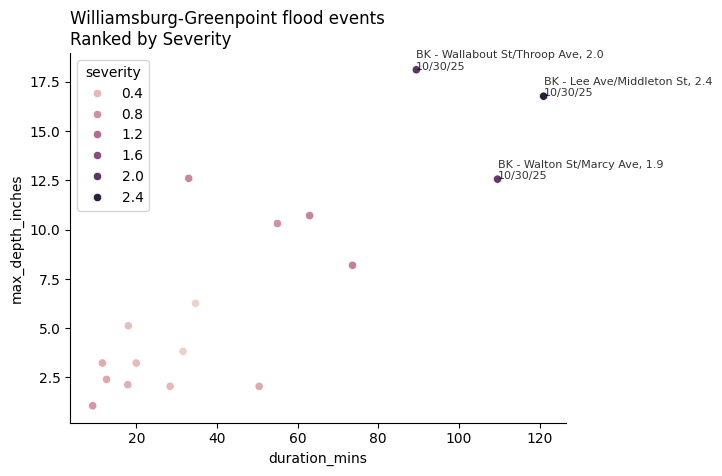

In [152]:
import seaborn as sns
from sklearn.preprocessing import RobustScaler

def calculate_severity(data, col1, col2):
    convert_cols = [col1,col2]
    print( convert_cols ) 
    for i in convert_cols:
        data[i] = pd.to_numeric(data[i] )

    # For both columns at once
    cols = [ col1, col2]
    data[['c1_scaled', 'c2_scaled']] = RobustScaler().fit_transform( data[cols] )

    # euclidian distance measure on 2-dimensions
    data['severity'] = (
        data['c1_scaled']**2 +
        data['c2_scaled']**2
    ) ** 0.5

    return data['severity']

filtered_floods['severity'] = calculate_severity( filtered_floods, 'duration_mins', 'max_depth_inches' )

fig,ax = plt.subplots()
sns.scatterplot(
    data = filtered_floods,
    x = 'duration_mins',
    y = 'max_depth_inches',
    hue='severity',
    ax=ax
)
ax.set_title(f"{selected_nta} flood events\nRanked by Severity", loc='left')

high_severity = filtered_floods[filtered_floods['severity'] > 1]
for _, row in high_severity.iterrows():
    ax.annotate(
        f"{row['sensor_name']}, {round(row['severity'],1)}\n{pd.to_datetime(row['flood_start_time']).strftime("%m/%d/%y")}",  # or sensor_id
        (row['duration_mins'], row['max_depth_inches']),
        fontsize=8,
        alpha=0.8
    )

sns.despine( ax=ax )

TO DO:  
Make sure this list somehow becomes a dropdown or something selectable, maybe a table?

In [155]:
print([f"{r['sensor_id']} <> {r['flood_start_time_ny']} <> {r['flood_end_time_ny']} <> {round(r['severity'],1)}" for i,r in high_severity.sort_values(by='severity', ascending=False).iterrows()])

# Simulating a selevted entry form the drop down menu here. 
selected_flood_event = 'BK-lee-ave-middleton-st-19qok0 <> 2025-10-30 14:58:43-04:00 <> 2025-10-30 16:59:44-04:00 <> 2.4'

['BK-lee-ave-middleton-st-19qok0 <> 2025-10-30 14:58:43-04:00 <> 2025-10-30 16:59:44-04:00 <> 2.4', 'BK-wallabout-st-throop-ave-19qu40 <> 2025-10-30 15:04:45-04:00 <> 2025-10-30 16:34:13-04:00 <> 2.0', 'BK-walton-st-marcy-ave-19qww0 <> 2025-10-30 15:00:12-04:00 <> 2025-10-30 16:49:48-04:00 <> 1.9']


## Set Up  
Prepare the local environment. This process take a few minutes.   
- Install missing libraries
- Install font (Source Sans)
- Create the folder structure html reads from

In [15]:
# %%capture
# print( "Starting Installs" )
# # Install missing libraries
# !pip install contextily
# !pip install weasyprint
# !pip install adjustText

# print("Installing Fonts")
# # Make sure the /contents is empty
# !rm -rf *
# # Download Source Sans 3
# !wget https://github.com/adobe-fonts/source-sans/raw/release/TTF/SourceSans3-Regular.ttf
# !wget https://github.com/adobe-fonts/source-sans/raw/release/TTF/SourceSans3-Bold.ttf

# Make a directory in the fonts folder for source
# Move the fonts file to the directory
# Update fonts cache
# !mkdir -p /usr/share/fonts/truetype/source
# !mv SourceSans3-Regular.ttf /usr/share/fonts/truetype/source
# !mv SourceSans3-Bold.ttf /usr/share/fonts/truetype/source
# !fc-cache -fv

print( 'Create charts folder' )
# Create visuals folder
# !mkdir -p /content/charts
visuals_folder = r"C:\Git_Repo\FloodAnalysis\auto-reports\content\charts" # change this back to colab folders

print( 'Installation as complete\nWe are ready to go!')

Create charts folder
Installation as complete
We are ready to go!


In [16]:
# import seaborn as sns
# import geopandas as gpd
import contextily as ctx
# import requests
import colour
import weasyprint
import matplotlib.font_manager as font_manager
import geocoder
# import pandas as pd
import os
import numpy as np
# import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import dates as mdates

dpi=300
blue = '#007acc'
light_blue = '#39A1FF'

# font_files = font_manager.findSystemFonts(fontpaths='/usr/share/fonts/' )
# for font_file in font_files: font_manager.fontManager.addfont(font_file)

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# mpl.rcParams['font.family'] = 'Source Sans 3'
# mpl.rcParams['font.weight'] = 'regular'

pd.set_option('display.max_columns', None)

print( "Set up complete" )

Set up complete


## Get Data  
If there are any errors (arrow turning red) please let me know, the problem is most probably external, we can let FloodNet team or MyCoast team know.
1. Boundaries (from Can's github)
1. Flood Net Sensors (sensors, events, depths)
2. 311 data
3. MyCoast data

In [156]:
selected_nta_data = ntas[ ntas['report_name'] == selected_nta ]
selected_nta_data

,BoroCode,BoroName,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels,geometry
41,3,Brooklyn,047,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),0,None,None,None,None,Williamsburg-Greenpoint,Williamsburg-Greenpoint,"MULTIPOLYGON (((-8232553.127 4973935.801, -823..."


### Join Data to Sensor Locations


In [157]:
sensors = gpd.sjoin( ntas[['labels','geometry']].to_crs(4326) , sensor_list )
filtered_sensors = sensors[ sensors['labels'] == selected_nta ]

print( filtered_sensors.shape[0] , 'sensors in', selected_nta )
filtered_sensors = filtered_sensors.drop(columns=['location','latitude','longitude','borough','zipcode','community_board','council_district','census_tract'])
filtered_sensors = filtered_sensors[filtered_sensors.columns[ ~filtered_sensors.columns.str.contains('computed')]] # Remvoe computed cols

filtered_sensors.head(3)

12 sensors in Williamsburg-Greenpoint


,labels,geometry,index_right,sensor_name,sensor_id,date_installed,tidally_influenced,street_name,nta,lowest_point_height_delta_inches,date_removed,days_active
41,Williamsburg-Greenpoint,"MULTIPOLYGON (((-73.95428 40.73911, -73.95423 ...",85,BK - Lee Ave/Middleton St,BK-lee-ave-middleton-st-19qok0,2023-03-09,No,Lee Avenue,BK0103,10.08,NaN,1181.475423
41,Williamsburg-Greenpoint,"MULTIPOLYGON (((-73.95428 40.73911, -73.95423 ...",172,BK - Walton St/Marcy Ave,BK-walton-st-marcy-ave-19qww0,2023-03-09,No,Walton Street,BK0103,10.91,NaN,1181.475423
41,Williamsburg-Greenpoint,"MULTIPOLYGON (((-73.95428 40.73911, -73.95423 ...",237,BK - Wallabout St/Harrison Ave,BK-wallabout-st-harrison-ave-19qrc0,2023-03-09,No,Wallabout Street,BK0103,12.83,NaN,1181.475423


In [158]:
from ast import literal_eval

# only events in filtered nta
events = flood_list[ flood_list['sensor_id'].isin( filtered_sensors['sensor_id'].unique() ) ].copy()

# event profiles are available in the data but needs some love
events['flood_profile_depth_inches'] = events['flood_profile_depth_inches'].apply( lambda x: literal_eval( x ) )
events['flood_profile_time_secs'] = events['flood_profile_time_secs'].apply( lambda x: literal_eval( x ) )
# events['flood_start_time'] = pd.to_datetime( events['flood_start_time'] )
display( events.head(2) )

# data_df becomes the depth and time profile
data_df = events[['sensor_id','sensor_name','flood_start_time','flood_end_time','flood_start_time_ny','flood_end_time_ny','flood_profile_depth_inches','flood_profile_time_secs']].set_index("sensor_id").explode(['flood_profile_depth_inches','flood_profile_time_secs'])
data_df['flood_start_time'] = pd.to_datetime( data_df['flood_start_time'] , utc=True )
data_df['time'] = data_df.apply( lambda x: x['flood_start_time'] + pd.Timedelta( seconds= x['flood_profile_time_secs']), axis=1 )
data_df = data_df[['flood_profile_depth_inches','flood_profile_time_secs','time']].reset_index()
data_df['depth_proc_mm'] = data_df['flood_profile_depth_inches'] * 25.4
data_df.head(2)

,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,flood_start_time_ny,flood_end_time_ny
135,BK - Wythe Ave/Wallabout St,BK-wythe-ave-wallabout-st-19qzo0,2025-06-10T16:01:00.000,2025-06-10T16:51:29.000,2.05,11.59,38.89,50.47,0,0,0,"[0.0, 0.63, 0.63, 0.91, 1.22, 1.61, 1.65, 1.97...","[0, 63, 126, 190, 253, 379, 443, 632, 695, 758...",2025-06-10 12:01:00-04:00,2025-06-10 12:51:29-04:00
149,BK - Wythe Ave/Wallabout St,BK-wythe-ave-wallabout-st-19qzo0,2025-06-19T20:52:03.000,2025-06-19T21:23:39.000,3.82,5.26,26.34,31.6,0,0,0,"[0.0, 1.81, 3.35, 3.82, 3.82, 3.15, 3.23, 3.07...","[0, 126, 189, 315, 379, 442, 568, 631, 758, 82...",2025-06-19 16:52:03-04:00,2025-06-19 17:23:39-04:00


,sensor_id,flood_profile_depth_inches,flood_profile_time_secs,time,depth_proc_mm
0,BK-wythe-ave-wallabout-st-19qzo0,0.0,0,2025-06-10 16:01:00+00:00,0.0
1,BK-wythe-ave-wallabout-st-19qzo0,0.63,63,2025-06-10 16:02:03+00:00,16.002


### Get sensor events between start time and end time.


### Get Raw Data

### Get 311 DATA  
311 data starts from the end date of the query and goes back 3 years.  
Do we want to update this to the first reported data?


In [159]:
polygon = selected_nta_data.dissolve().to_crs(4326)
polygon.geometry = polygon.geometry.simplify(0.001).buffer( 0.002 ).simplify(0.001)

def get_311_data( polygon ):
    '''Query 311 data for the selected CDTA'''
    data_query = 'https://data.cityofnewyork.us/resource/erm2-nwe9.json'
    # Add more descriptors here
    descriptors = ['Street Flooding (SJ)','Catch Basin Clogged/Flooding (Use Comments) (SC)', 'Manhole Overflow (Use Comments) (SA1)' ]
    descriptors_filter = ' OR '.join([f"descriptor='{d}'" for d in descriptors])
    selectors = 'unique_key,created_date,agency,complaint_type,descriptor,status,latitude,longitude'

    start_date = pd.to_datetime(query_date_end) - pd.Timedelta(days=360*3)
    # start_date to the beginning of the year
    start_date = start_date.replace(month=1,day=1).date().strftime('%Y-%m-%d')

    polygon_geom = polygon.geometry.values[0]

    url = f"{data_query}?$where=within_polygon(location, '{polygon_geom}') AND created_date>'{start_date}' AND ({descriptors_filter})&$select={selectors}&$limit=5000"
    # print( url )
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Error {response.status_code}")
    else:
        data_311 = pd.DataFrame( response.json() )
    data_311 = gpd.GeoDataFrame(data_311.drop(['latitude','longitude'],axis=1), geometry=gpd.points_from_xy(data_311.longitude, data_311.latitude), crs=4326 )
    return data_311

data_311 = get_311_data( polygon )
print( data_311.shape[0] , "rows in 311 data" )
data_311.head(3)

C:\Users\cansu\AppData\Local\Temp\ipykernel_11072\1304844149.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  polygon.geometry = polygon.geometry.simplify(0.001).buffer( 0.002 ).simplify(0.001)


1107 rows in 311 data


,unique_key,created_date,agency,complaint_type,descriptor,status,geometry
0,59494090,2023-11-19T11:59:00.000,DEP,Sewer,Catch Basin Clogged/Flooding (Use Comments) (SC),Closed,POINT (-73.94851 40.72453)
1,59511701,2023-11-21T18:53:00.000,DEP,Sewer,Catch Basin Clogged/Flooding (Use Comments) (SC),Closed,POINT (-73.95217 40.71749)
2,59518042,2023-11-22T16:59:00.000,DEP,Sewer,Catch Basin Clogged/Flooding (Use Comments) (SC),Closed,POINT (-73.96171 40.7019)


### Get MyCoast Data

In [160]:
def get_myCoast_data():

    db_len = 1000
    paged_data = pd.DataFrame()
    count = 1
    while db_len > 998:
      url = f'https://mycoast.org/blueurchin-js/arcgis/can-ny.php?page={count}'

      headers = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/116.0'}
      response = requests.get(url, headers=headers )
      data = response.json()

      data = pd.DataFrame( data['features'] )
      db_len = data.shape[0]
      print( db_len )
      data['coords'] = data['geometry'].apply( lambda x: x['coordinates'])
      data['lon'] = data['coords'].str[0]
      data['lat'] = data['coords'].str[1]
      data['picUrl'] = data['properties'].apply( lambda x: x['picUrl'])
      data['comment'] = data['properties'].apply( lambda x: x['comment'])
      data['photo_date'] = data['properties'].apply( lambda x: x['photo_date'])
      data['photo_time'] = data['properties'].apply( lambda x: x['photo_time'])
      data['id'] = data['properties'].apply( lambda x: x['id'])
      data['datetime'] = pd.to_datetime( data['photo_date'] + " " + data['photo_time'] , format='mixed' )
      data = data.drop( ['geometry','properties','coords','photo_date','photo_time','type'], axis=1 )
      data = gpd.GeoDataFrame( data=data , geometry=gpd.points_from_xy(data['lon'],data['lat']), crs=4326 )
      paged_data = pd.concat( [paged_data , data] )
      count = count + 1

    return paged_data

myCoast_data = get_myCoast_data()
myCoast_data.head()

1000
766


,lon,lat,picUrl,comment,id,datetime,geometry
0,-78.828359,43.030351,https://cdn.mycoast.photos/2026/06/01131610/d0...,Tracking monthly/ seasonal changes,239583,2026-06-01 08:37:00,POINT (-78.82836 43.03035)
1,-78.186150,42.999987,https://cdn.mycoast.photos/2026/06/02104856/a7...,,239656,2026-05-28 10:33:00,POINT (-78.18615 42.99999)
2,-76.881945,42.535077,https://cdn.mycoast.photos/2026/05/10051840/08...,,237479,2026-05-09 19:50:00,POINT (-76.88194 42.53508)
3,-76.920615,42.609149,https://cdn.mycoast.photos/2026/05/01151845/21...,Seneca Lake still 3” below flood level with mo...,236748,2026-05-01 15:16:00,POINT (-76.92062 42.60915)
4,-76.962280,42.710575,https://cdn.mycoast.photos/2026/04/28182045/47...,Normally 10-15 ft of sloping beach,236509,2026-04-28 16:04:00,POINT (-76.96228 42.71058)


## GENERATE PLOTS  
All charts and maps that will be used in the report will be generated here. The resulting charts are not shown but are stored in `/content/charts/`. If you click on the folders sign to the left and go into charts folder, you can double-click on the images to view them.  
- Main map
- Inset map
- 311 heatmap
- Flooded days timeline
- Zoom-in events


### Map 1
- Countains:
  - Flood sensor locations
  -  frequency of days with floods  
  - 311 locations
- Annotations are positioned automatically
- Many complex symbology is generated in layers.  
- Produces **map1.png**

In [161]:
def create_local_data(df):
  local_data = df.copy()
  local_data['clean_depth_in'] = local_data['depth_proc_mm'] / 25.4
  local_data['time_NY'] = local_data['time'].dt.tz_convert('America/New_York').dt.tz_localize(None)
  local_data = local_data.join( sensors[['sensor_id','sensor_name','latitude','longitude']].set_index('sensor_id') , on='sensor_id', how='left')
  local_data['sensor_display_name'] = local_data['sensor_name'].str.split(" - ").str[1].str.strip()
  return local_data

local_data = create_local_data( data_df )

# Get max depth for each deployment per day
daily_max_flood = local_data.groupby( ['sensor_id', pd.Grouper(key='time_NY', freq='1d')] ).agg({'clean_depth_in':'max' }).reset_index()

#Count Flooded Days
flooded_days = daily_max_flood.groupby('sensor_id').size().reset_index().rename(columns={0:'flooded_days'})

# First date sensor recorded data, this will be the annotation
first_record = local_data.groupby('sensor_id').agg({'time_NY':'min','sensor_display_name':'first'})

# Join Data
flooded_days_map = local_data.groupby('sensor_id').agg({'latitude':'first','longitude':'first'}).join( flooded_days.set_index('sensor_id') ).join( first_record )
flooded_days_map['time_NY'] = flooded_days_map['time_NY'].dt.strftime('%Y-%m-%d')

# GeoDataFrame
flooded_days_map = gpd.GeoDataFrame(flooded_days_map, geometry=gpd.points_from_xy(flooded_days_map.longitude, flooded_days_map.latitude), crs=4326).to_crs(3857)

# Calculate # of flood events
num_flood_events = events.groupby('sensor_id',as_index=False).size().rename(columns={'size':'num_flood_events'})
flooded_days_map = flooded_days_map.join( num_flood_events.set_index('sensor_id') )

flooded_days_map.head()

,latitude,longitude,flooded_days,time_NY,sensor_display_name,geometry,num_flood_events
sensor_id,,,,,,,
BK-humboldt-st-norman-ave-2k9nco,40.727447,-73.945762,1,2025-10-30,Humboldt St / Norman Ave,POINT (-8231604.572 4972222.899),1
BK-kent-ave-wallabout-st-19r2g0,40.699336,-73.960584,1,2025-10-30,Kent Ave/Wallabout St,POINT (-8233254.55 4968094.433),1
BK-lee-ave-middleton-st-19qok0,40.700775,-73.954629,3,2025-07-31,Lee Ave/Middleton St,POINT (-8232591.642 4968305.727),3
BK-meserole-ave-newel-st-2if0k0,40.728355,-73.94935,1,2025-10-30,Newel Ave/ Meserole St,POINT (-8232003.986 4972356.28),1
BK-richardson-st-n-11th-st-1x59w1,40.718256,-73.952593,1,2025-10-30,Richardson St/N 11th St,POINT (-8232364.996 4970872.889),1


3 sensors with no events
Map Plotted, check C:\Git_Repo\FloodAnalysis\auto-reports\content\chartsmap1.png


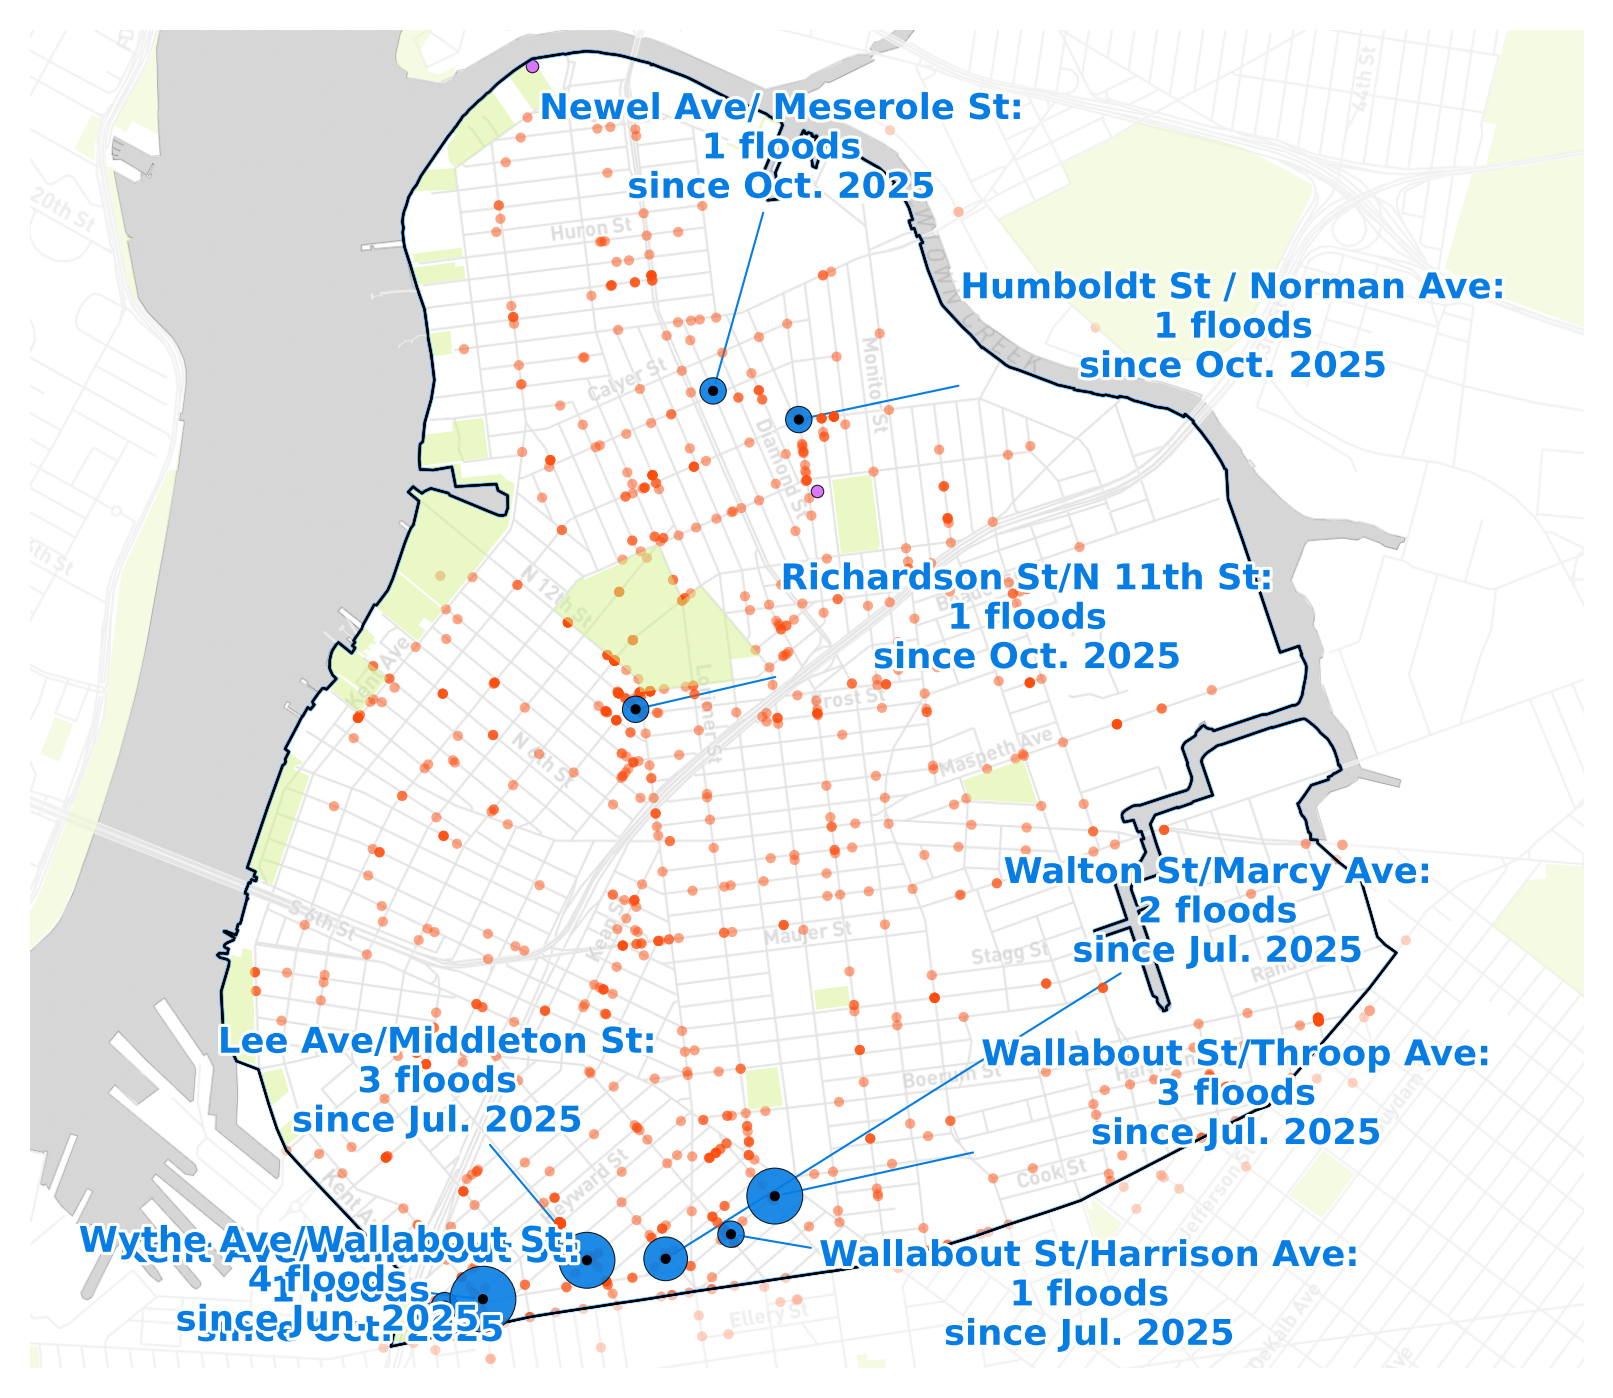

In [162]:
import matplotlib.patheffects as pe
from adjustText import adjust_text
import matplotlib

local_cdta = ntas[ntas['report_name'] == selected_nta ].to_crs(3857)
other_cdta = ntas[ntas['report_name'] != selected_nta ].to_crs(3857)

def plot_map1():
    fig,ax = plt.subplots( figsize=(5.225,4.5), dpi=dpi )

    # 1. ---------------  BOUNDARIES ------------------
    local_cdta.plot( ax=ax , fc = 'none' , ec = light_blue, alpha = 0.8 , zorder = 10 )
    other_cdta.plot( ax=ax , fc = 'white' , ec = 'none', alpha = 0.5, zorder = 10 )

    # ZOOM and SIZE ADJUSTMENT
    # Define plot bounds by local cdta + padding
    pad = 100
    ax.set_xlim( local_cdta['geometry'].bounds.minx.values[0]-pad , local_cdta['geometry'].bounds.maxx.values[0]+pad )
    ax.set_ylim( local_cdta['geometry'].bounds.miny.values[0]-pad , local_cdta['geometry'].bounds.maxy.values[0]+pad )

    # is x or y bounds larger?
    x_size = abs( (local_cdta['geometry'].bounds.minx.values[0]-pad) - (local_cdta['geometry'].bounds.maxx.values[0]+pad) )
    y_size = abs( (local_cdta['geometry'].bounds.miny.values[0]-pad) - (local_cdta['geometry'].bounds.maxy.values[0]+pad) )
    if x_size > y_size:
        ratio = 5.225 / 4.5
        y_mid = ( local_cdta['geometry'].bounds.miny.values[0] + local_cdta['geometry'].bounds.maxy.values[0] ) / 2
        y_pad = ( x_size / ratio ) / 2
        ax.set_ylim( y_mid - y_pad , y_mid + y_pad )
    else:
        ratio = 4.5 / 5.225
        x_mid = ( local_cdta['geometry'].bounds.minx.values[0] + local_cdta['geometry'].bounds.maxx.values[0] ) / 2
        x_pad = ( y_size / ratio ) / 2
        ax.set_xlim( x_mid - x_pad , x_mid + x_pad )

    # Sensors with Flooding
    with_flooding = flooded_days_map[ flooded_days_map['flooded_days'].notnull() ]

    # 2. ------------- WITH FLOODING --------------
    # 2a. BLUE CIRCLE
    t = sns.scatterplot(
        x = with_flooding.geometry.x, y = with_flooding.geometry.y,
        ax = ax,
        facecolor = "#057de4", edgecolor = 'black',
        linewidth = 0.25,
        size = with_flooding[ 'flooded_days' ], sizes = ( 40 , 250 ),
        alpha = 0.9, zorder = 12,
    )

    # 2b. BLACK DOT
    flooded_days_map.plot( ax=ax, markersize = 6 , fc = 'black' , ec = 'none' , alpha = 1 , zorder = 13 )
    # 311 orange points
    data_311.to_crs(3857).plot( ax=ax , fc = '#fe4c0c' , ec = 'none', alpha = 0.5 , zorder = 2 , markersize=6 )

    # Plot myCoast
    myCoast_localdata = myCoast_data.sjoin( local_cdta.to_crs(4326) )
    myCoast_localdata = myCoast_localdata.drop_duplicates(subset=['lat','lon'])
    if myCoast_localdata.shape[0] > 0:
      myCoast_localdata.to_crs( 3857 ).plot( ax=ax , fc = "#d966ff", ec='k', lw=0.25, alpha=0.9 , markersize= 9, zorder=3)

    # 2c. Annotations
    texts = with_flooding.apply(
        lambda x: ax.annotate(
            text = f"{x['sensor_display_name']}:\n{int(x['num_flood_events']) } floods\nsince {pd.to_datetime(x['time_NY']).strftime('%b. %Y')}",
            xy = ( x.geometry.x , x.geometry.y ) ,
            ha = 'center' , va = 'bottom' ,
            xycoords = 'data' ,
            fontsize = 8.5, fontweight='bold' , color = '#057de4', zorder=100 ,
            path_effects=[pe.withStroke(linewidth=1.5, foreground="w")]),
        axis = 1
    )

    # 3. ------------- NO FLOODING --------------
    no_flooding = flooded_days_map[ flooded_days_map['flooded_days'].isnull() ]
    if no_flooding.shape[0] > 0:
        t2 = no_flooding.plot( ax=ax, markersize=50, fc='none', ec='black', lw=0.5 , zorder=10 )
    else:
        t2 = None

    no_events = filtered_sensors[ ~filtered_sensors['sensor_id'].isin( flooded_days_map.index ) ]
    if no_events.shape[0] > 0:
        print( no_events.shape[0] , "sensors with no events")
        no_events.to_crs(3857).plot( ax=ax, markersize=50, fc='none', ec='black', lw=0.5 , zorder=10 )

    # Plot Parks
    all_parks = gpd.read_file( 'https://raw.githubusercontent.com/cankadir/FloodAnalysis/main/DATA/NYC_Parks_Simplified_FIlled.geojson' )
    all_parks = all_parks.to_crs(3857)
    all_parks.plot( ax=ax , fc = '#d4f28d' , ec = 'none', alpha = 0.5 , zorder = 2 )

    # Adjust Text so they are not intersecting
    exp_val = 1.25
    adjust_text(
        texts = texts.tolist(),
        ax=ax,
        avoid_self=True,
        x = with_flooding.geometry.x, y = with_flooding.geometry.y,
        expand = ( exp_val,exp_val ),
        force_text=(0.25,0.25),
        ensure_inside_axes = True,
        iter_lim = 4000,
        arrowprops=dict(arrowstyle="-", color="#057de4" , lw=0.5) )

    ctx.add_basemap( ax, source = mapbox_url, attribution="" )

    ax.axis('off')
    ax.legend([], frameon=False)
    plt.tight_layout(pad=0)
    # plt.savefig( map1_path , dpi = dpi , bbox_inches='tight' ,transparent="True", pad_inches=0)
    # plt.close()

map1_path = os.path.join( visuals_folder , "map1.png" )
plot_map1()
print( f"Map Plotted, check {visuals_folder}map1.png")

### Map 2: NYC Inset Map
This is a very simple map of sensor locations.

Map Plotted, check C:\Git_Repo\FloodAnalysis\auto-reports\content\charts\insetmap.png


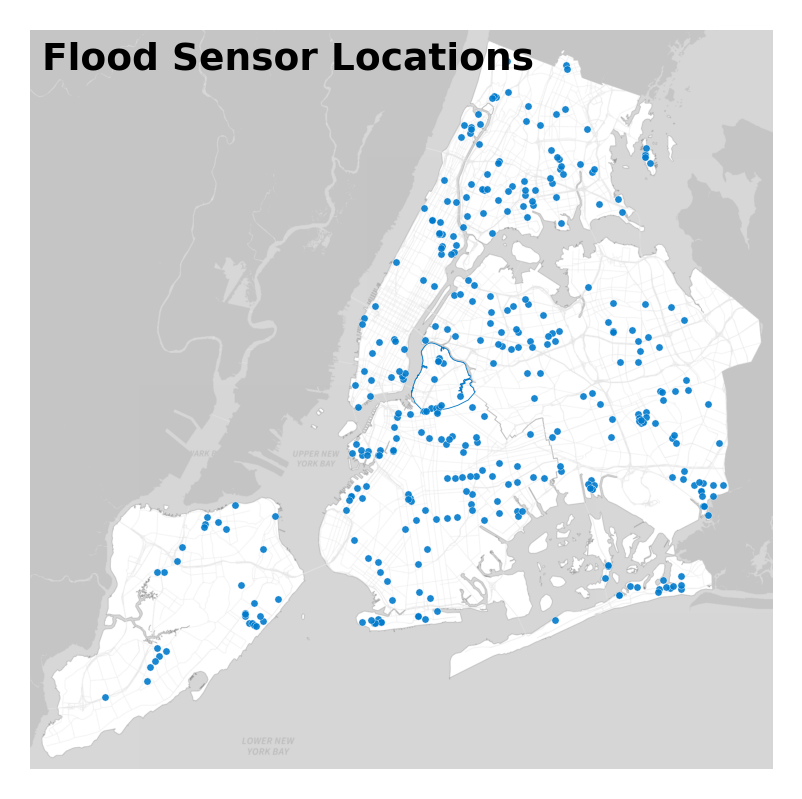

In [163]:
def plot_insetMap():
    
    fig,ax = plt.subplots(figsize=(2.475,2.475), dpi=dpi)

    projected_cdta = ntas.dissolve().to_crs(3857)
    local_cdta.to_crs(3857).plot(ax=ax , fc='none' , ec=blue, lw=0.2 )
    sensor_list.to_crs(3857).plot( ax=ax , fc = blue , ec = 'w', alpha = 0.9 , markersize = 3, lw=0.1 )

    # Define plot bounds by local cdta + padding
    pad = 1000
    ax.set_xlim( projected_cdta['geometry'].bounds.minx.values[0]-pad , projected_cdta['geometry'].bounds.maxx.values[0]+pad )
    ax.set_ylim( projected_cdta['geometry'].bounds.miny.values[0]-pad , projected_cdta['geometry'].bounds.maxy.values[0]+pad )

    ctx.add_basemap( ax, source= mapbox_url, attribution="" )
    ax.axis('off')

    ax.annotate( 'Flood Sensor Locations', xy=( ax.get_xlim()[0]+1000, ax.get_ylim()[1]-1000 ) , ha='left', va='top', fontsize=9, fontweight='bold', color='black' , zorder=100 )

    fig.tight_layout(pad=0)
    # fig.savefig( insetmap_path , dpi = dpi, bbox_inches='tight' ,transparent="True", pad_inches=0)
    # plt.close()

insetmap_path = os.path.join( visuals_folder , "insetmap.png" )
plot_insetMap()

print( f"Map Plotted, check {insetmap_path}")

### 311 Heatmap
This is the chart at the bottom of page 2.  
Blue gradient is the flooded days count per month  
Orange gradient is the number of 311 requests per month.  

The legend items for the charts are generated separatly but with in this block

In [164]:
year_now = pd.Timestamp.now().year
year_past = year_now - 3

print( year_now, year_past )
# year_list = list(range( year_past +1 , year_now+1 , 1))
# year_list

2026 2023


In [165]:
sensor_ids_str = ','.join(f"'{s}'" for s in filtered_sensors['sensor_id'].unique() )
measured_events_query = (
    f"{measured_events_url}?$where="
    f"flood_start_time >= '{year_past}-01-01T00:00:00' "
    f"AND sensor_id IN ({sensor_ids_str})"
    f"AND flood_start_time < '{year_now}-01-01T00:00:00' "
    f"AND max_depth_inches > 1"
    f"&$limit=10000"
)

r = requests.get( measured_events_query )
data = r.json()
all_events = pd.DataFrame().from_records(data)
print( all_events.shape[0] )

all_events['flood_profile_depth_inches'] = all_events['flood_profile_depth_inches'].apply( lambda x: literal_eval( x ) )
all_events['flood_profile_time_secs'] = all_events['flood_profile_time_secs'].apply( lambda x: literal_eval( x ) )
all_events['flood_start_time'] = pd.to_datetime( all_events['flood_start_time'] )

all_events.head(2)

43


,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs
0,BK - Humboldt St / Norman Ave,BK-humboldt-st-norman-ave-2k9nco,2025-10-30 19:01:58,2025-10-30T19:56:58.000,10.31,22,33,55,44.9,0,0,"[0.0, 0.47, 0.67, 3.9, 6.89, 8.66, 9.17, 9.45,...","[0, 60, 120, 240, 420, 540, 600, 660, 720, 780..."
1,BK - Kent Ave/Wallabout St,BK-kent-ave-wallabout-st-19r2g0,2023-09-29 12:19:12,2023-09-29T13:25:27.000,11.73,26.27,39.97,66.24,54.77,0,0,"[0.0, 0.59, 1.5, 3.39, 4.06, 4.8, 4.8, 5.59, 5...","[0, 63, 126, 189, 252, 316, 379, 442, 505, 631..."


In [166]:
# event profiles are available in the data but needs some love
all_depths = all_events[['sensor_id','sensor_name','flood_start_time','flood_end_time','flood_profile_depth_inches','flood_profile_time_secs']].set_index("sensor_id").explode(['flood_profile_depth_inches','flood_profile_time_secs'])

all_depths['time'] = all_depths.apply( lambda x: x['flood_start_time'] + pd.Timedelta( seconds= x['flood_profile_time_secs']), axis=1 )
all_depths = all_depths[['sensor_name','flood_profile_depth_inches','flood_profile_time_secs','time']].reset_index()
all_depths['depth_proc_mm'] = all_depths['flood_profile_depth_inches'] * 25.4
all_depths['clean_depth_in'] = all_depths['flood_profile_depth_inches']
all_depths.head(2)
all_depths['time_NY'] = pd.to_datetime(all_depths['time'], utc=True ).dt.tz_convert('America/New_York').dt.tz_localize(None)
all_depths.head(3)

,sensor_id,sensor_name,flood_profile_depth_inches,flood_profile_time_secs,time,depth_proc_mm,clean_depth_in,time_NY
0,BK-humboldt-st-norman-ave-2k9nco,BK - Humboldt St / Norman Ave,0.0,0,2025-10-30 19:01:58,0.0,0.0,2025-10-30 15:01:58
1,BK-humboldt-st-norman-ave-2k9nco,BK - Humboldt St / Norman Ave,0.47,60,2025-10-30 19:02:58,11.938,0.47,2025-10-30 15:02:58
2,BK-humboldt-st-norman-ave-2k9nco,BK - Humboldt St / Norman Ave,0.67,120,2025-10-30 19:03:58,17.018,0.67,2025-10-30 15:03:58


311 Heatmap is Plotted, it is here C:\Git_Repo\FloodAnalysis\auto-reports\content\charts\heatmap_311.png


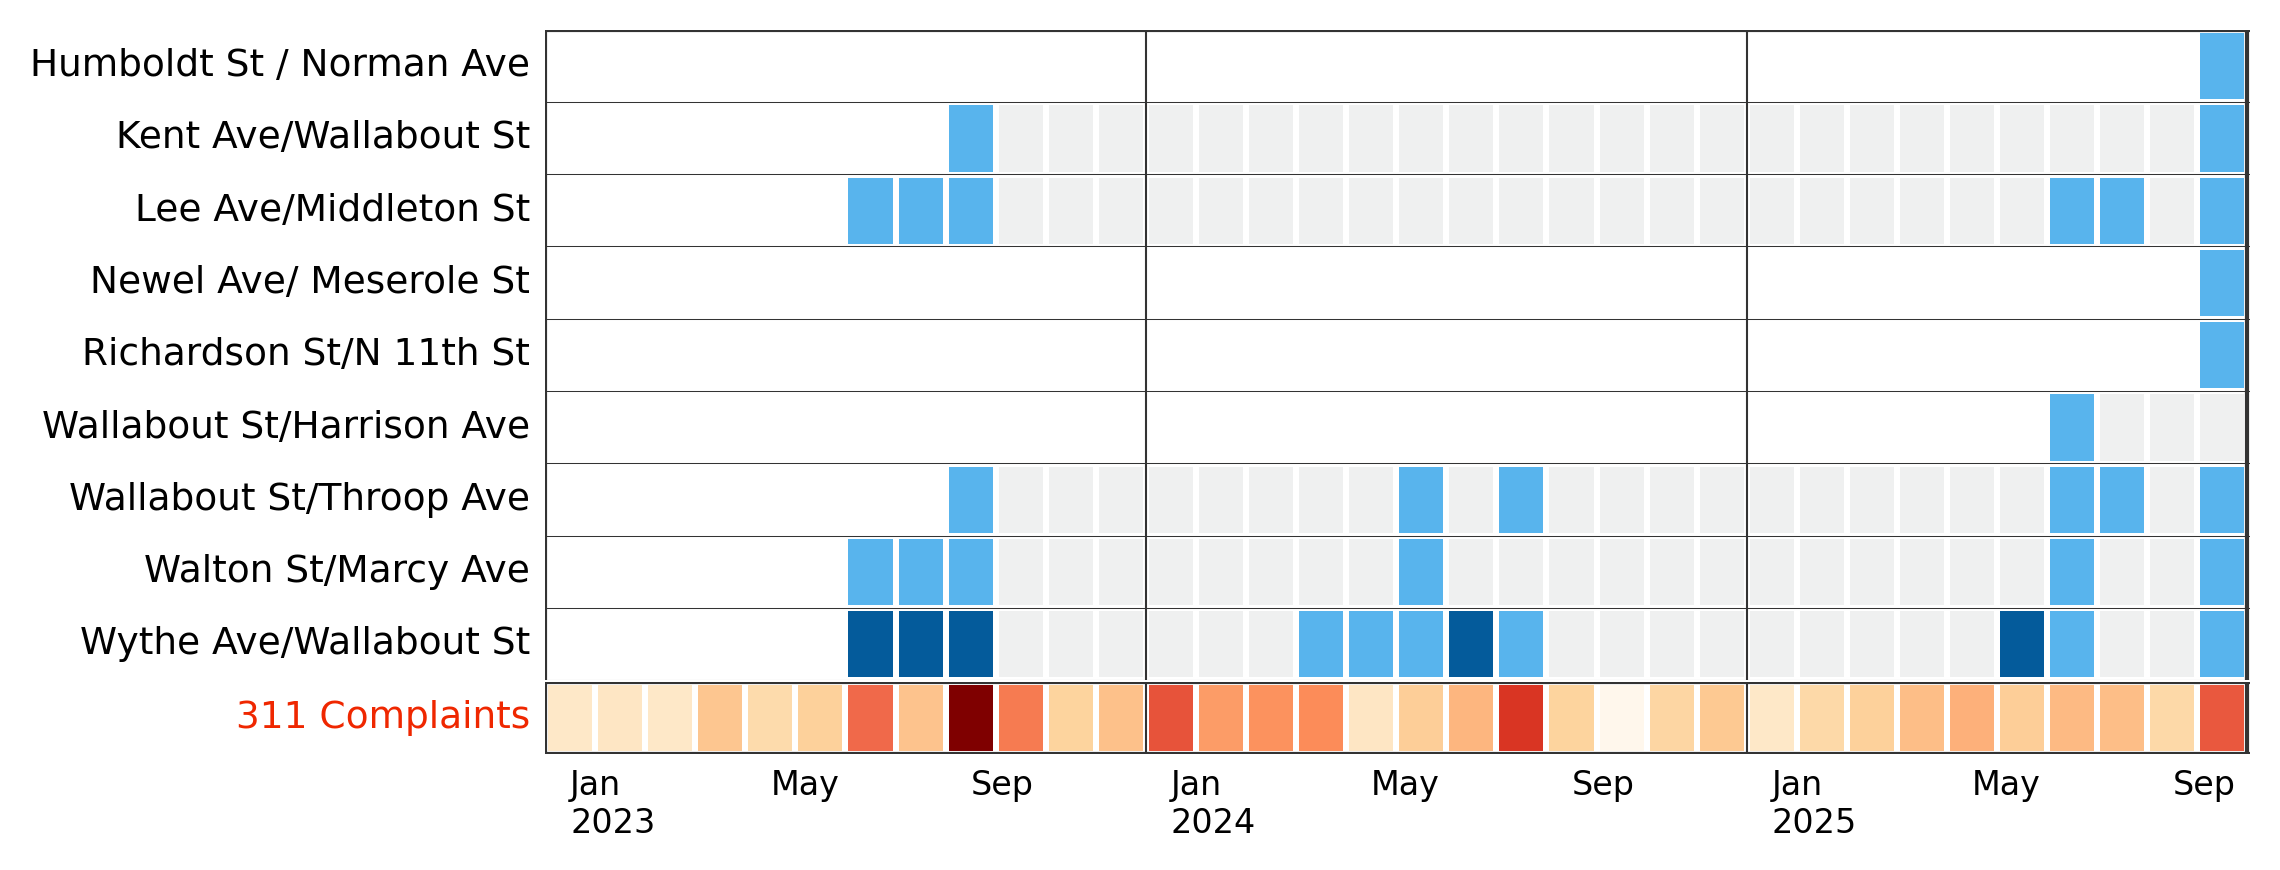

In [167]:
# Segmented Color Map
def make_Ramp( ramp_colors ):
    from colour import Color
    # from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.colors import ListedColormap, LinearSegmentedColormap

    color_ramp = ListedColormap( ramp_colors )
    return color_ramp

def prepare_data( filtered_local_data ):
    f = '1MS'

    # Daily max value per sensor
    sensors_over_time = filtered_local_data.groupby( ['sensor_name', pd.Grouper(key='time_NY', freq='1D')] ).agg({'clean_depth_in':'max'}).reset_index()

    # Number of days with flooding per month, only when the days are there
    sensors_over_time = sensors_over_time.groupby( ['sensor_name', pd.Grouper(key='time_NY', freq=f)] ).agg({'clean_depth_in':'count'}).reset_index()

    # Create an empty list of months (from first day) to join the previous flooded days counts
    all_months = pd.DataFrame( index = pd.date_range( filtered_local_data['time_NY'].dt.round("1d").min() , filtered_local_data['time_NY'].max() , freq=f ) ).reset_index().rename(columns={'index':'time_NY'} )
    all_months['sensor_name'] = [filtered_local_data['sensor_name'].unique()] * all_months.shape[0]
    all_months = all_months.explode('sensor_name')
    all_months['time_NY'] = all_months['time_NY'].dt.round("1d")

    t = all_months.join( sensors_over_time.set_index(['sensor_name','time_NY']), on=['sensor_name','time_NY'] )

    pt = t.pivot( index='sensor_name', columns='time_NY', values='clean_depth_in' )
    # if pt with 0 only after the recorded value per row
    for i,r in pt.iterrows():
        cols = pt.columns
        has_started = False
        for c in cols:
            if not pd.isna(r[c]):  has_started = True
            if has_started:
                if pd.isna(r[c]) :
                    pt.loc[i,c] = 0

    data_311['created_date'] = pd.to_datetime(data_311['created_date'])
    filtered_311 = data_311[ data_311['created_date'] < filtered_local_data['time_NY'].max() ]

    monthly_311 = filtered_311.groupby( pd.Grouper(key='created_date', freq=f) ).agg({'unique_key':'nunique'}).reset_index().rename(columns={'unique_key':'count'})
    monthly_311['ind'] = '311 Complaints'
    monthly_311 = monthly_311.pivot( index='ind', columns='created_date', values='count' )

    # join and drop to equalize the ranges
    pt = pd.concat( [pt,monthly_311] ).drop( index="311 Complaints" )
    pt.index = [i.split(' - ')[1] if '-' in i else i for i in pt.index ]

    return pt, monthly_311

custom_ramp = make_Ramp( ['#EFF0F0' ,"#ABDAEF","#58B4ED", '#0586CE', '#045B9B'] )
pt, monthly_311 = prepare_data( all_depths )

def plot_heatmap():

    values = ['No Flood', 'Minimal Flooding', 'Minor Flood', 'Moderate Flooding', 'Major Flooding']
    fig, axs = plt.subplots( nrows = 2 , figsize=(7.7,3), height_ratios=[pt.shape[0],1] , sharex=True , dpi=dpi )

    # ------------------ Flood VIZ ------------------
    ax = axs[0]
    sns.heatmap( pt, ax=ax, cmap= custom_ramp, cbar=False, lw=1, linecolor='w' )

    ax.tick_params( axis='x', which='both', bottom=False, top=False, labelbottom=False )
    ax.tick_params( axis='y', which='both', left=False , labelsize=9, pad=0.1 )
    ax.set_ylabel('')
    ax.set_xlabel('')

    [ ax.axhline( i+0.495 , color='#333' , lw=0.25 ) for i in ax.get_yticks()]

    # draw frame
    ax.axhline( 0, color='#333', lw=1 )
    ax.axvline( 0, color='#333', lw=1 )
    ax.axvline( ax.get_xticks()[-1]+0.5 , color='#333', lw=1 )

    # ----------------- 311 VIZ -----------------
    ax = axs[1]
    sns.heatmap(
        monthly_311, ax=ax,
        cmap= 'OrRd', cbar=False,
        lw=1, linecolor='w',
    )

    ax.tick_params( axis='y', which='both', left=False, rotation=0 , labelsize=9, pad=0.1 )
    ax.tick_params( axis='x', which='both', bottom=False , pad=0.1 )

    ax.set_ylabel('')
    ax.set_xlabel('')

    # draw frame
    ax.axhline( 0, color='#333', lw=1 )
    ax.axhline( 1, color='#333', lw=1 )
    ax.axvline( 0, color='#333', lw=1 )
    ax.axvline( ax.get_xticks()[-1]+0.5 , color='#333', lw=1 )

    # x-ticks
    ax.set_xticks( np.arange( 0.5 , ax.get_xticks()[-1] , 4 ) )
    xticklabels = [ pd.to_datetime(x.get_text()).strftime('%b') if pd.to_datetime(x.get_text()).strftime('%b') != 'Jan' else f"{pd.to_datetime(x.get_text()).strftime('%b')}\n{pd.to_datetime(x.get_text()).strftime('%Y')}"  for x in ax.get_xticklabels() ]
    ax.set_xticklabels( xticklabels , rotation=0 , ha='left', va='top' , fontsize=8 )
    ax.set_yticklabels( ['311 Complaints'], color='#Ef2700' )

    [ axs[1].axvline(ticks-0.5, color='#333', lw=0.5 ) for labels,ticks in zip(ax.get_xticklabels(),ax.get_xticks()) if "Jan" in labels.get_text() ]
    [ axs[0].axvline(ticks-0.5, color='#333', lw=0.5 ) for labels,ticks in zip(ax.get_xticklabels(),ax.get_xticks()) if "Jan" in labels.get_text() ]

    ax.set_xlim( ax.get_xlim()[0] , ax.get_xlim()[1]+0.05 )
    plt.tight_layout( h_pad=0.025 )
    # plt.savefig( heatmap_path , bbox_inches='tight' ,transparent=False, pad_inches=0, dpi=dpi)
    # plt.close()
heatmap_path = os.path.join( visuals_folder , "heatmap_311.png" )
plot_heatmap()
print( f"311 Heatmap is Plotted, it is here {heatmap_path}")


#### Custom Legends

C:\Users\cansu\AppData\Local\Temp\ipykernel_11072\741816507.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fake_data = pd.concat( [fake_data, pd.DataFrame([None]) ] )
C:\Users\cansu\AppData\Local\Temp\ipykernel_11072\741816507.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout( pad=0 )


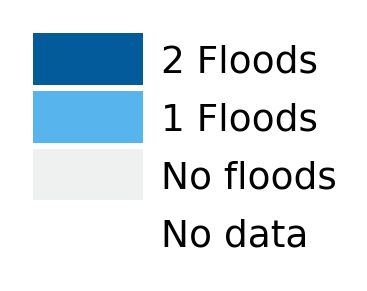

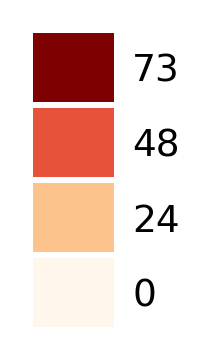

In [168]:
def flooded_days_legend( path ):
    max_flooded_day = pt.max().max()
    fake_data = pd.DataFrame( np.linspace(  max_flooded_day,0, 3 ) )
    fake_data = pd.concat( [fake_data, pd.DataFrame([None]) ] )

    fig,ax = plt.subplots( figsize=(0.5,1), dpi=dpi )

    sns.heatmap(
        fake_data,ax=ax,
        cmap = custom_ramp, cbar = False,
        lw = 1, linecolor = 'w',
    )

    ax.tick_params( axis='x', which='both', bottom=False, top=False, labelbottom=False )
    ax.tick_params( axis='y', which='both', left=False, labelleft=False, labelright=True , labelsize=9, pad=0.1, rotation=0 )
    ax.set_yticklabels( [ f"{int(max_flooded_day)} Floods", f"{int(max_flooded_day/2)} Floods", "No floods", "No data" ])

    fig.tight_layout( pad=0 )
    # fig.savefig( path , bbox_inches='tight' ,transparent="True", pad_inches=0, dpi=dpi )
    # plt.close()

def legend_311( path ):
    max_complaint = monthly_311.max().max()
    fake_data = pd.DataFrame( np.linspace(  max_complaint , 0, 4 ) )

    fig,ax = plt.subplots( figsize=(0.5,1), dpi=dpi )

    sns.heatmap(
        data = fake_data, ax=ax,
        cmap = 'OrRd' , cbar = False,
        lw = 1, linecolor = 'w'
    )

    ax.tick_params( axis='x', which='both', bottom=False, top=False, labelbottom=False )
    ax.tick_params( axis='y', which='both', left=False, labelleft=False, labelright=True , labelsize=9, pad=0.1, rotation=0 )
    ax.set_yticklabels( [str(int(i)) for i in np.linspace(  max_complaint , 0 , 4 )]  )

    fig.tight_layout( pad=0 )
    # fig.savefig( path , bbox_inches='tight' ,transparent="True", pad_inches=0, dpi=dpi )
    # plt.close()

# Flood legend
legend_floods_path = os.path.join( visuals_folder , "legend_floods.png" )
flooded_days_legend(legend_floods_path)

# 311 legend
legend_311_path = os.path.join( visuals_folder , "legend_311.png" )
legend_311(legend_311_path);

### Flooded Days  
We use data from `sensors list metadata` to find out what to hightlight.  
Metadata is stored on the drive folder [here](https://docs.google.com/spreadsheets/d/1LA17hb-oD7wxpPPIiKw6ywPNO3yWygklLwSEh-FXETM/edit?usp=drive_link).

In [169]:
# event_startdate ,... in America/New York
highlighted_sensor,event_startdate,event_enddate,severity =  selected_flood_event.split(" <> ")
event_startdate = pd.to_datetime( event_startdate )
event_enddate = pd.to_datetime( event_enddate )
print( highlighted_sensor,event_startdate,event_enddate )

BK-lee-ave-middleton-st-19qok0 2025-10-30 14:58:43-04:00 2025-10-30 16:59:44-04:00


In [170]:
hili_depths = all_depths[ all_depths['sensor_id'] == highlighted_sensor ]
hili_depths.head()

,sensor_id,sensor_name,flood_profile_depth_inches,flood_profile_time_secs,time,depth_proc_mm,clean_depth_in,time_NY
176,BK-lee-ave-middleton-st-19qok0,BK - Lee Ave/Middleton St,0.0,0,2023-07-02 21:33:49,0.0,0.0,2023-07-02 17:33:49
177,BK-lee-ave-middleton-st-19qok0,BK - Lee Ave/Middleton St,0.47,63,2023-07-02 21:34:52,11.938,0.47,2023-07-02 17:34:52
178,BK-lee-ave-middleton-st-19qok0,BK - Lee Ave/Middleton St,1.18,189,2023-07-02 21:36:58,29.972,1.18,2023-07-02 17:36:58
179,BK-lee-ave-middleton-st-19qok0,BK - Lee Ave/Middleton St,3.58,315,2023-07-02 21:39:04,90.932,3.58,2023-07-02 17:39:04
180,BK-lee-ave-middleton-st-19qok0,BK - Lee Ave/Middleton St,3.43,567,2023-07-02 21:43:16,87.122,3.43,2023-07-02 17:43:16


Updated -> Lollipop chart

time is now!
2025-10-30 14:58:43-04:00 2025-10-30 16:59:44-04:00


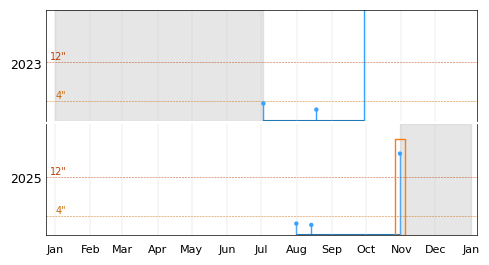

In [171]:
hili_events = all_events[ all_events['sensor_id'] == highlighted_sensor ].copy()
grid_colors = ['#ca6702','#bb3e03','#ae2012']
values = ['Minor Flood', 'Moderate Flood', 'Major Flood']

hili_events['year'] = hili_events['flood_start_time'].dt.year
hili_events = hili_events[['sensor_name','sensor_id','flood_start_time','flood_end_time','max_depth_inches','year']]
hili_events['max_depth_inches'] = pd.to_numeric( hili_events['max_depth_inches'] )

hili_events['flat_date'] = hili_events['flood_start_time'].dt.strftime("1900-%m-%d  %H:%M:%S")
hili_events['flat_date'] = pd.to_datetime( hili_events['flat_date'] )

years = sorted(hili_events['year'].unique())
fig,axs = plt.subplots( nrows = len(years) , sharex=True, sharey=True, figsize = (5,2.75) )
for i,year in enumerate( years ):
    ax = axs[i]
    
    events_1y = hili_events[ hili_events['year'] == year ]
    
    ax.vlines( ymax=events_1y['max_depth_inches'], ymin=0, x=events_1y['flat_date'] , alpha=1 , lw=1, color='#39a1ff' )
    ax.scatter( y=events_1y['max_depth_inches'], x=events_1y['flat_date'], s=10 , marker='o' ,fc='#39a1ff' , ec='none', zorder=5 )
    ax.hlines( y=0, xmin=events_1y['flat_date'].min(), xmax = events_1y['flat_date'].max() )

    # grey span at start and end
    if (events_1y['flat_date'].min() - pd.to_datetime(f'01-01-1900 00:00') > pd.Timedelta('1 days') )& (int(year) == int(hili_events['year'].min())):
        ax.axvspan(
            xmin = pd.to_datetime(f'01-01-1900 00:00'),
            xmax = events_1y['flat_date'].min(),
            color='#cecece', alpha=0.5, zorder=1
        )

    if (pd.to_datetime(f'12-31-1900 23:59') - events_1y['flat_date'].max() > pd.Timedelta('1 days')) & (int(year) == int(hili_events['year'].max())):
        ax.axvspan(
            xmin = events_1y['flat_date'].max(),
            xmax = pd.to_datetime(f'12-31-1900 23:59'),
            color='#cecece', alpha=0.5, zorder=1
        )
        
    sns.despine( ax=ax, bottom=True, right=False )
    ax.set_ylim( 0, np.where( events_1y['max_depth_inches'].max() > 8, events_1y['max_depth_inches'].max() + 6, 14 ) )
    ax.set_ylabel( year, rotation=0 , labelpad=3, fontsize = 9 , ha='right', va='center' )

    # format y-axis as %b %d
    ax.xaxis.set_major_formatter( mdates.DateFormatter('%b') )
    # every month
    ax.xaxis.set_major_locator( mdates.MonthLocator() )

    ax.set_xlim( pd.to_datetime('24-12-1899 00:00:00',dayfirst=True) , pd.to_datetime('05-01-1901 23:59:59',dayfirst=True) )
    ax.tick_params(axis='y', which='both', left=False, labelleft=False )
    ax.tick_params( axis='x' , labelsize=8 , bottom=False )

    # Horizontal grid (2 12 24  )
    [ ax.axhline(t, ls='--', lw=0.4, alpha=0.8, color=grid_colors[n]) for n,t in enumerate([4,12,24]) ]
    [ ax.annotate(f'{t}"', xy=( pd.to_datetime('01-01-1900')+pd.Timedelta(days=10),t) ,color=grid_colors[n], va='bottom', ha='right', fontsize=7 ) for n,t in enumerate([4,12,24]) ]
    # grid
    [ ax.axvline( pd.to_datetime( f'{i}-01-1900' ), color="#cecece", lw=0.25, alpha=1 ) for i in range(1,13)]

    ax.spines['left'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)

    if i==0:
        ax.spines['top'].set_visible(True)
        ax.spines['top'].set_linewidth(0.5)
    if i==len(axs)-1:
        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_linewidth(0.5)

    # hiligthed event -> box is here. 
    if year == event_startdate.year :
        print( "time is now!" )
        print( event_startdate , event_enddate )
        event_converted_startdate = pd.to_datetime( f'1900-{event_startdate.month}-{event_startdate.day} {event_startdate.hour}:00:00' )
        event_converted_enddate = pd.to_datetime( f'1900-{event_enddate.month}-{event_enddate.day} {event_enddate.hour}:00:00' )

        event_midpoint = event_converted_startdate + ( event_converted_enddate - event_converted_startdate ) / 2

        event_converted_startdate = event_midpoint - pd.Timedelta( days = 4.5 )
        event_converted_enddate = event_midpoint + pd.Timedelta( days = 4.5 )

        # make span with vmin and vmax
        ax.fill_between( [ event_converted_startdate , event_converted_enddate ] , 0 , events_1y['max_depth_inches'].max() + 3 , ec='#ff7f0e', fc='none', alpha=1 , zorder=150, capstyle='round', joinstyle='round' )
  
fig.tight_layout( w_pad=0.005, h_pad=0.25 )
flood_timeline_path = os.path.join( visuals_folder , "flood_timeline.png" )
fig.savefig( flood_timeline_path , transparent="True" , bbox_inches='tight', pad_inches=0.02 , dpi=dpi )
#   plt.close()

### Zoom-In Chart
This chart overlaps:
1. Sensor readings  
1a. Hightlight
2. Rainfall OR Tide
3. The rainboot (at 16")  

Since non of these items are in the same data space, this chart uses 3 axis.
Make sure the measurements look reasonable

#### Download Tide Data  
We are re-downloading the data for this one event with better buffers are without filtering non-zero values to be able to show start and end.  

**Open Weather** data will be added here.

In [172]:
# Needed query setup
time_pad = 1
buffered_start = event_startdate - pd.Timedelta(hours=time_pad)
buffered_end = event_enddate + pd.Timedelta(hours=time_pad)
event_sensor = highlighted_sensor
print( event_sensor )
print( event_startdate , event_enddate ) # in local time
print( buffered_start , buffered_end ) # in local time

BK-lee-ave-middleton-st-19qok0
2025-10-30 14:58:43-04:00 2025-10-30 16:59:44-04:00
2025-10-30 13:58:43-04:00 2025-10-30 17:59:44-04:00


In [173]:
is_tidal  = True if sensor_list[ sensor_list['sensor_id'] == highlighted_sensor ]['tidally_influenced'].values[0] == "Yes" else False
print( is_tidal )

False


In [ ]:
URL = "https://api.floodnet.nyc/v1/graphql"
def request_tidedata( event_start, event_end, tidal_gauge ):
    result = requests.post(URL, json={
        'query': '''
            query TideData($dev_id: String!, $start_time: timestamptz!, $end_time: timestamptz!) {
                tidal_data(where: {
                    dev_id: {_eq: $dev_id},
                    time: {
                        _gt: $start_time,
                        _lt: $end_time,
                    },
                }) {
                    time
                    dev_id
                    navd88_mm
                    mllw_mm
                    mhhw_mm
                }
            }
            ''',
            'variables': {
                'dev_id': tidal_gauge,
                'start_time': event_start.isoformat(),
                'end_time': event_end.isoformat(),
            },
    })

    data = result.json()['data']['tidal_data']
    data = pd.DataFrame(data)
    data['time'] = pd.to_datetime(data['time'])
    data = data.sort_values('time')
    return data

def adjust_tidedata( event_start, event_end, tidal_gauge ):
    delta_time = (event_end - event_start).total_seconds() / 360
    print( delta_time )
    if delta_time < 1000:
        data = request_tidedata( event_start, event_end, tidal_gauge )
    else:
        intervals = pd.date_range( event_start, event_end, freq='4D')
        data = pd.DataFrame()
        for i in range( len(intervals) - 1 ):
            data = pd.concat( [data, request_tidedata( intervals[i], intervals[i+1], tidal_gauge )] )

    gr = data.groupby( pd.Grouper(key='time', freq='18min') ).agg({'mhhw_mm': 'mean'} ).reset_index()

    return gr

def get_precipitation( buffered_start, buffered_end ):
    import io

    sensor_name = 'nyc-micronet-bknyrd'
    sensor_name = sensor_name.split('-')[-1]

    buffered_start_utc = buffered_start.tz_convert("UTC").isoformat().replace( "+00:00" , "Z")
    buffered_end_utc = buffered_end.tz_convert("UTC").isoformat().replace( "+00:00" , "Z")

    timerange = f"{buffered_start}/{buffered_end}"
    payload = "variables[]=precip:incremental@mm&variables[]=precip@mm&variables[]=precip_max_intensity@mm/min"
    url = f'https://api.nysmesonet.org/data/dynserv/coned/5min/nyc/{timerange}?{payload}'

    data = requests.get( url )
    df = pd.read_csv( io.StringIO( data.content.decode('utf-8') ) , sep="," , parse_dates=['datetime'])
    df = df[ df['station'] == sensor_name.upper() ].copy()
    df['time_NY'] = df['datetime'].dt.tz_convert('America/New_York').dt.tz_localize(None)
    df['precip_max_intensity [in/min]'] = 0.03937008 * df['precip_max_intensity [mm/min]']
    df['precip_max_intensity [ft/min]'] = 0.00328084 * df['precip_max_intensity [mm/min]']
    return df

background_data = pd.DataFrame()
print( f"sensor is {'' if is_tidal else 'not'} tidally influenced")
if is_tidal:
    nearest_gauge = pd.read_csv( r"C:\Git_Repo\FloodAnalysis\DATA\tide\nearest_tidal_meta.csv")
    nearest_gauge[ nearest_gauge['sensor_name'] == sensor_list[ sensor_list['sensor_id'] == event_sensor ]['sensor_name'].values[0] ]
    nearest_gauge_id = nearest_gauge['nearest_tidal_id'].values[0]
    background_data = adjust_tidedata( buffered_start, buffered_end , nearest_gauge_id )
    background_data['time_NY'] = background_data['time'].dt.tz_convert('America/New_York').dt.tz_localize(None)
    background_data['mhhw_ft'] = background_data['mhhw_mm'] * 0.00328084
else:
    background_data = get_precipitation( buffered_start, buffered_end )

background_data.head()

sensor is not tidally influenced
Pluvial


,station,datetime,precip_incremental [mm],precip_utc [mm],precip_max_intensity [mm/min],time_NY,precip_max_intensity [in/min],precip_max_intensity [ft/min]
2,BKNYRD,2025-10-30 18:00:00+00:00,0.51,20.64,0.00,2025-10-30 14:00:00,0.00000,0.000000
20,BKNYRD,2025-10-30 18:05:00+00:00,1.19,21.83,0.00,2025-10-30 14:05:00,0.00000,0.000000
38,BKNYRD,2025-10-30 18:10:00+00:00,1.15,22.98,0.00,2025-10-30 14:10:00,0.00000,0.000000
56,BKNYRD,2025-10-30 18:15:00+00:00,1.48,24.46,0.46,2025-10-30 14:15:00,0.01811,0.001509
74,BKNYRD,2025-10-30 18:20:00+00:00,0.49,24.95,0.00,2025-10-30 14:20:00,0.00000,0.000000


#### Plot zoom-in Chart

C:\Users\cansu\AppData\Local\Temp\ipykernel_11072\1140591113.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels( [f'{i:.0f}"' for i in ax.get_yticks()] , color='#2093f2' )


2025-10-30 14:58:43 2025-10-30 16:59:44
2025-10-30 13:58:43-04:00 2025-10-30 17:59:44-04:00


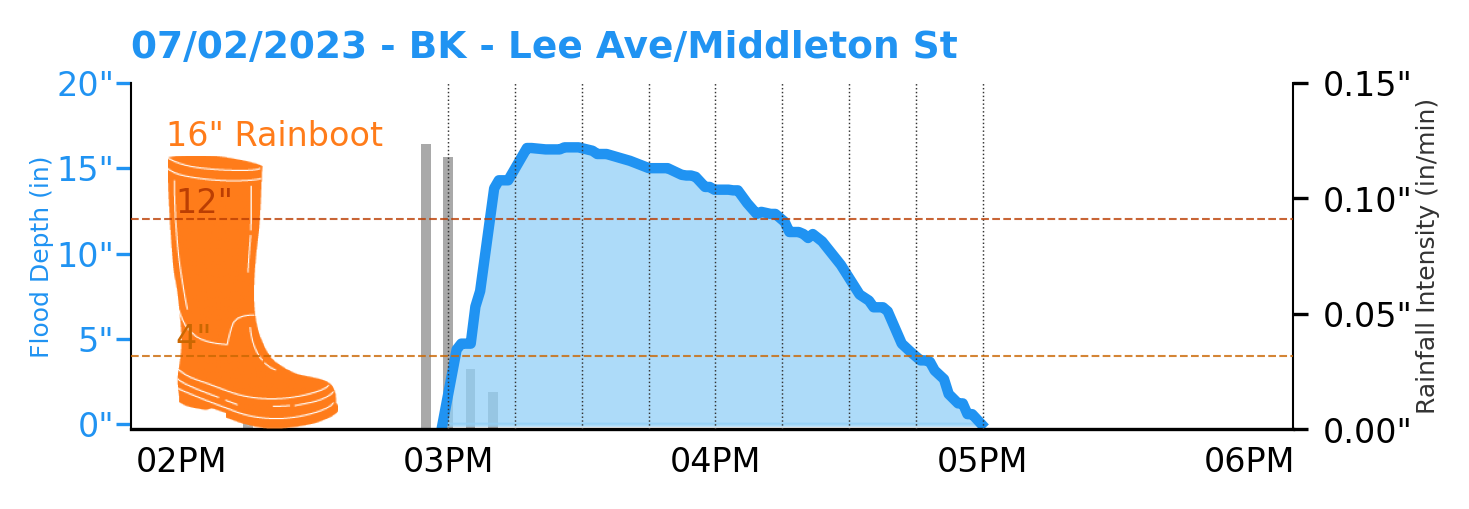

In [184]:
grid_colors = ['#ca6702','#bb3e03','#ae2012']
fig,ax = plt.subplots( figsize=(5,1.5) , dpi=dpi )

def plot_zoom(filtered_data):
    buffer_start_local = buffered_start.tz_localize(None)
    buffered_end_local = buffered_end.tz_localize(None)

    filtered_data['time_NY'] = pd.to_datetime( filtered_data['time_NY'], errors='coerce' )
    filtered_data['clean_depth_in'] = pd.to_numeric( filtered_data['clean_depth_in'] , errors='coerce' )

    ax.plot( filtered_data['time_NY'], filtered_data['clean_depth_in'], lw=2.5, color='#2093f2' , label='Flooding' )
    ax.fill_between( filtered_data['time_NY'], filtered_data['clean_depth_in'], color="#92d0f7", alpha=0.75 )

    # chart y -> 20" at least.
    ylim = 20 if filtered_data['clean_depth_in'].max() < 20 else filtered_data['clean_depth_in'].max()+6
    ax.set_ylim( -0.3 , ylim )

    # hlines on x ticks similar to grid
    [ ax.axvline( t , color='#333', lw=0.35, ls=":", zorder = 14 ) for t in ax.get_xticks() ]
    [ ax.axhline(t, ls='--', lw=0.5, alpha=0.8, color=grid_colors[n] , zorder=1100) for n,t in enumerate([4,12,24])  ]
    [ ax.annotate(f'{t}"', xy=( buffer_start_local , t) ,color=grid_colors[n], va='bottom', ha='left', fontsize=8 , zorder=1100 ) for n,t in enumerate([4,12,24]) ]

    # Styling
    sns.despine(left=False, ax=ax )
    ax.tick_params(axis='y', which='both', left=True, labelleft=True , labelsize=8 , pad=0.5, color='#2093f2' )
    ax.tick_params( axis='x', labelsize=8 , pad=0.5, bottom=False )
    ax.set_yticklabels( [f'{i:.0f}"' for i in ax.get_yticks()] , color='#2093f2' )
    ax.set_ylabel('Flood Depth (in)', fontsize=6, labelpad=0.5, color='#2093f2')
    ax.set_title( f"{hili_depths['time_NY'].min().strftime("%m/%d/%Y")} - {hili_depths['sensor_name'].unique()[0]}" , fontsize=9 , color='#2093f2', loc='left' , ha='left', fontweight='bold' )

    delta_hours = filtered_data['time_NY'].dt.hour.max() - filtered_data['time_NY'].dt.hour.min()
    # Common Styling
    ax.xaxis.set_major_locator( mdates.HourLocator(interval= 1 if delta_hours < 12 else 2) )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%I%p'))
    ax.set_xlim( [buffer_start_local - pd.Timedelta(minutes=10) , buffered_end_local.tz_localize(None) + pd.Timedelta(minutes=10)] )

filtered_data_plot = hili_depths[ (hili_depths['time_NY'] > buffered_start.tz_localize(None)) & (hili_depths['time_NY'] < buffered_end.tz_localize(None)) ].sort_values(by='time', ascending=True )
plot_zoom( filtered_data_plot )

# ---- PLOT BACKGROUND DATA ----
def plot_bgdata():
    if not is_tidal:

        # background_data_filtered = background_data[ (background_data['time_NY'] >= event_startdate_ny ) & (background_data['time_NY'] <= event_enddate_ny ) ]
        ax2.bar( background_data['time_NY'], background_data['precip_max_intensity [in/min]'] , width=0.0015 , fc='#676767', ec='none', alpha=0.56 , label='5min Precipitaion (in/min)' )

        # only focus on the event time
        # ax2.set_xlim( event_startdate_ny , event_enddate_ny )

        # # add " to highset y-tick
        ax2.set_ylim( 0 , 0.1 if background_data[ 'precip_max_intensity [in/min]' ].max() < 0.1 else background_data[ 'precip_max_intensity [in/min]' ].max() * 1.2 )
        ax2.set_yticks( ax2.get_yticks() , labels=[f"{i:.2f}\"" for i in ax2.get_yticks()] )
        ax2.set_ylabel( "Rainfall Intensity (in/min)" , fontsize=6, labelpad=0.8, color='#333' )

    else:

        ax2.plot( background_data['time_NY'], background_data['mhhw_ft'] , color='#555', lw=0.5 , ls="--" ,alpha=0.9 , label='Tide levels' )
        ax2.set_ylim( np.floor(background_data['mhhw_ft'].min() * 1.2) , np.ceil(background_data['mhhw_ft'].max() * 1.2) )
        ax2.set_ylabel('Tide Level - mhhw (ft)', rotation=90 , labelpad=3, fontsize = 6 )

    # spines and styling
    for i in ['left','top','bottom']: ax2.spines[i].set_visible(False)
    ax2.tick_params(axis='y',which='both',left=False, labelleft=False , labelsize=8 )
    ax2.yaxis.tick_right()
    ax.spines['left'].set_linewidth(0.5)
    ax2.spines['right'].set_linewidth(0.5)
    # ax2.set_xlim( [event_startdate_ny - pd.Timedelta(minutes=10) , event_enddate_ny + pd.Timedelta(minutes=10)] )

# do not worry about background data (tide/prcp) if the data does not exist.
if background_data.shape[0] > 0:
  ax2 = ax.twinx()
  ax2.set_zorder(1)
  ax2.set_facecolor("none")
  plot_bgdata()

# ---- Plot RAINBOOT
# Plots the rainboot to axin axes
height_ratio = 16 / (ax.get_ylim()[1] - ax.get_ylim()[0])
axin = ax.inset_axes( [0.005 , 0 , 0.2 , height_ratio ]  , zorder=100)    # create new inset axes in data coordinates

def plot_rainboot():
    # A new axis is formed -> height of the axis is plot height / flood height, to match 16
    import matplotlib.image as mpimg
    img_id = '1zja2MnKBovz7WLrKfCSM0Wau5C5QL_aW'
    img_link = f'https://drive.google.com/uc?export=view&id={img_id}'
    img_data = requests.get(img_link).content
    with open('rainboot.png', 'wb') as handler:
        handler.write(img_data)

    rainboot = mpimg.imread('rainboot.png')

    axin.imshow( rainboot )
    axin.axis('off')

plot_rainboot()

# ---- Plot 16" Rainboot Annotation
axrb = ax.inset_axes( [0 , 0 , 1 , 1 ]  , zorder=41 )    # create new inset axes in data coordinates
axrb.annotate( '16" Rainboot' , xy=( 0.03 , height_ratio + 0.01 ), xycoords='axes fraction' , ha='left', va='bottom', fontsize=8 , color='#FF7C1A' )
axrb.axis('off')

# # -- -- -- -- Order plots  -- -- -- --
ax.set_zorder(2)
ax.set_facecolor("none")
axin.set_zorder(40)
axin.set_facecolor("none")
axrb.set_zorder(45)
axrb.set_facecolor("none")

print(filtered_data_plot["time_NY"].min() , filtered_data_plot["time_NY"].max())
print( buffered_start, buffered_end )


# ---- SAVE ----
# popup_chart_path = os.path.join( visuals_folder , "flood_timeline_zoom.png" )
# print( f"Zoom-In chart is saved at {popup_chart_path}")

# fig.savefig( popup_chart_path ,bbox_inches='tight', transparent="True" , pad_inches=0 , dpi=dpi )


## PHOTOS FROM MYCOASTS  
Paginate myCoast REST until you reach a page with less than 1000 enteries.

### How are the images choosen?  
- Add a 1/4 mile buffer to the sensor location until 50 photos are found.
- Try to choose only images with comments. If there are more then a few images with comments, prioritize them first.
- From the remainder choose 2 random images

In [ ]:
# check if myCoast_photos folder exists in the visual folder
if not os.path.exists( os.path.join( visuals_folder , 'myCoast_photos' ) ): os.makedirs( os.path.join( visuals_folder , 'myCoast_photos' ) )
photos_folder = os.path.join( visuals_folder , 'myCoast_photos' )

myCoast_data = myCoast_data[ myCoast_data['picUrl'] != False ]
print( myCoast_data.shape[0] )
myCoast_data.head()

1728


,lon,lat,picUrl,comment,id,datetime,geometry
0,-76.881945,42.535077,https://cdn.mycoast.photos/2026/05/10051840/08...,,237479,2026-05-09 19:50:00,POINT (-76.88194 42.53508)
1,-73.966041,41.369435,https://cdn.mycoast.photos/2026/05/05170547/3a...,,237057,2026-05-05 16:59:00,POINT (-73.96604 41.36944)
2,-76.920615,42.609149,https://cdn.mycoast.photos/2026/05/01151845/21...,Seneca Lake still 3” below flood level with mo...,236748,2026-05-01 15:16:00,POINT (-76.92062 42.60915)
3,-76.962280,42.710575,https://cdn.mycoast.photos/2026/04/28182045/47...,Normally 10-15 ft of sloping beach,236509,2026-04-28 16:04:00,POINT (-76.96228 42.71058)
4,-76.867512,42.423212,https://cdn.mycoast.photos/2026/04/23174947/75...,,236111,2026-04-23 17:00:00,POINT (-76.86751 42.42321)


In [ ]:
dist = 0.5
myCoast_photos_count = 0

local_cdta = ntas[ntas['labels'] == report_nta ].to_crs(3857)
other_cdta = ntas[ntas['labels'] != report_nta ].to_crs(3857)

# Grow the search radius until we have at least 10 pictures.
while myCoast_photos_count < 30 :
    dist = dist + 0.15
    local_cdta['buffer_geometry'] = local_cdta['geometry'].to_crs(2263).buffer( 5280*dist ).to_crs(4326)
    buffer_cdta = local_cdta.set_geometry( 'buffer_geometry' )

    myCoast_cdta = myCoast_data.sjoin( buffer_cdta )
    myCoast_photos_count = myCoast_cdta.shape[0]

# i need 4 pictures, preferably with comments
myCoast_cdta = myCoast_cdta.sort_values( by='datetime' )
myCoast_cdta_wcomments = myCoast_cdta[ ~myCoast_cdta['comment'].isin(['','0',0]) ]
print( myCoast_cdta.shape[0],'images', "\n" , myCoast_cdta_wcomments.shape[0] ,'images with comments' )

display( myCoast_cdta_wcomments.head() )

63 images 
 9 images with comments


,lon,lat,picUrl,comment,id,datetime,geometry,index_right,BoroCode,BoroName,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels,geometry_right
124,-73.789491,40.849337,https://cdn.mycoast.photos/2024/06/01153952/92...,April 2020 Full Moon\n,168413,2020-04-09 01:00:00,POINT (-73.78949 40.84934),26,2,Bronx,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island,"MULTIPOLYGON (((-8214210.714 4988088.044, -821..."
121,-73.789491,40.849337,https://cdn.mycoast.photos/2024/06/01153832/e7...,April 2020 Full Moon\n,168401,2020-04-09 14:06:00,POINT (-73.78949 40.84934),26,2,Bronx,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island,"MULTIPOLYGON (((-8214210.714 4988088.044, -821..."
0,-73.789000,40.853430,https://cdn.mycoast.photos/2024/05/31165708/19...,This location has rain as the primary cause bu...,167426,2020-11-11 22:56:00,POINT (-73.789 40.85343),26,2,Bronx,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island,"MULTIPOLYGON (((-8214210.714 4988088.044, -821..."
993,-73.789000,40.853430,https://cdn.mycoast.photos/2024/05/31170025/da...,Similar to past complaints on this site.,167445,2020-11-13 15:37:00,POINT (-73.789 40.85343),26,2,Bronx,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island,"MULTIPOLYGON (((-8214210.714 4988088.044, -821..."
901,-73.789564,40.849287,https://cdn.mycoast.photos/2024/06/01150613/e3...,Also have video,168169,2021-03-28 11:40:00,POINT (-73.78956 40.84929),26,2,Bronx,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island,"MULTIPOLYGON (((-8214210.714 4988088.044, -821..."


In [ ]:
if dist < 1:
  photo_title = "What does flooding look like in your neighborhood?"
else:
  photo_title = "What does similar flooding look like in New York City?"

In [ ]:
import matplotlib.image as mpimg

if myCoast_cdta_wcomments.shape[0] > 2:
  myCoast_selection = myCoast_cdta_wcomments.sample(2)
else:
  myCoast_selection = pd.concat([
      myCoast_cdta_wcomments,
      myCoast_cdta.sample(2-myCoast_cdta_wcomments.shape[0])
  ])

img_urls = myCoast_selection['picUrl'].values
print( img_urls )

['https://cdn.mycoast.photos/2024/06/01150613/e34900134ea101409caf09169b95df057216592c.jpg'
 'https://cdn.mycoast.photos/2024/06/01145640/1741e0d6444fac899e964c4b2532f327d09b83f0-scaled.jpg']


In [ ]:
def reverse_geocode(lat,lon):
    # use arcgis to get the address
    g = geocoder.arcgis( [lat,lon] , method='reverse' )
    address = g.address
    address = " ".join(address.split(' ')[1:])
    address = address.replace( ', New York' ,'' )
    return address

myCoast_selection['address'] = myCoast_selection['geometry'].apply( lambda x: reverse_geocode( x.y, x.x ) )
myCoast_selection['time_formatted'] = myCoast_selection['datetime'].dt.strftime('%b %d, %Y')

myCoast_selection

,lon,lat,picUrl,comment,id,datetime,geometry,index_right,BoroCode,BoroName,CountyFIPS,CDTA2020,CDTAName,CDTAType,NTA2020,NTAName,NTAAbbrev,NTAType,report_name,labels,geometry_right,address,time_formatted
901,-73.789564,40.849287,https://cdn.mycoast.photos/2024/06/01150613/e3...,Also have video,168169,2021-03-28 11:40:00,POINT (-73.78956 40.84929),26,2,Bronx,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island,"MULTIPOLYGON (((-8214210.714 4988088.044, -821...","Ditmars St, Bronx, 10464","Mar 28, 2021"
835,-73.789601,40.849252,https://cdn.mycoast.photos/2024/06/01145640/17...,"Also, I have a video of this.",168102,2021-07-24 00:22:00,POINT (-73.7896 40.84925),26,2,Bronx,005,BX10,BX10 Co-op City-Throgs Neck (CD 10 Approximation),0,BX1003,Pelham Bay-Country Club-City Island,PlhmBy,0,City Island,City Island,"MULTIPOLYGON (((-8214210.714 4988088.044, -821...","Ditmars St, Bronx, 10464","Jul 24, 2021"


## View MyCoast Images

delete existing images in the dir
geocoding
<[OK] Arcgis - Reverse [90 Ditmars St, Bronx, New York, 10464]>


'rm' is not recognized as an internal or external command,
operable program or batch file.


<[OK] Arcgis - Reverse [150-198 Cross St, Bronx, New York, 10464]>


FileNotFoundError: [Errno 2] No such file or directory: '/content/charts/myCoast_photos/img_5397-scaled.jpeg'

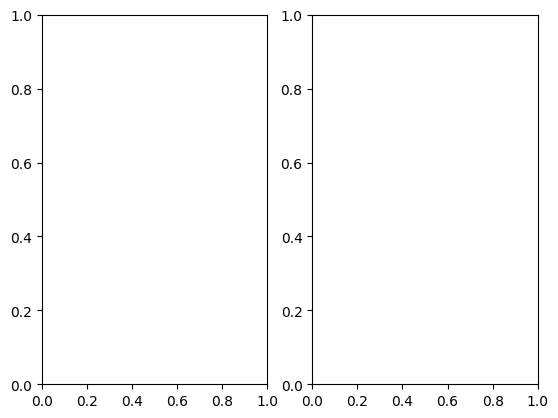

In [ ]:
# @markdown Run this cell again to view the **myCoast** Images with comments.
# @markdown
# @markdown This cell, reselectes 2 images from the previous selection and then reverse geocodes the locations using ESRI geocoder.

print( 'delete existing images in the dir' )
!rm -f /content/charts/myCoast_photos/*

import matplotlib.image as mpimg

if myCoast_cdta_wcomments.shape[0] > 2:
  myCoast_selection = myCoast_cdta_wcomments.sample(2)
else:
  myCoast_selection = pd.concat([
      myCoast_cdta_wcomments,
      myCoast_cdta.sample(2-myCoast_cdta_wcomments.shape[0])
  ])

img_urls = myCoast_selection['picUrl'].values

def reverse_geocode(lat,lon):
    # use arcgis to get the address
    g = geocoder.arcgis( [lat,lon] , method='reverse' )
    print( g )
    address = g.address
    address = " ".join(address.split(' ')[1:])
    address = address.replace( ', New York' ,'' )
    return address

print('geocoding')
myCoast_selection['address'] = myCoast_selection['geometry'].apply( lambda x: reverse_geocode( x.y, x.x ) )
myCoast_selection['time_formatted'] = myCoast_selection['datetime'].dt.strftime('%b %d, %Y')

def add_line_breaks(text, n=10):
  # break the long text
  words = text.split()
  new_text = ""
  count = 0

  for word in words:
    new_text += word + " "
    count += 1

    if count == n:
      new_text += "\n"
      count = 0
  return new_text

fig,axs = plt.subplots( ncols=2 )

for count,(i,r) in enumerate(myCoast_selection.iterrows()):
  ax = axs[count]

  url = r['picUrl']
  img_data = requests.get(url).content
  file_name = url.split("/")[-1]
  file_name = f"/content/charts/myCoast_photos/{file_name}"
  with open( file_name , 'wb') as handler: handler.write(img_data)

  img = mpimg.imread( file_name )
  ax.imshow( img )
  ax.axis('off')

  comment = r['comment']
  comment = add_line_breaks( comment, 6 )

  ax.text( s = comment , x=0, y=1 ,transform=ax.transAxes , va='bottom')
  ax.text( s = r['address'] , x=0, y=0 ,transform=ax.transAxes , va='top')


## Create PDF  
Download all necessary content into assets folder and prepare variables.  
Replace variables in HTML, print to index.html, convert to pdf.  
Download PDF, open in browser.


In [ ]:
# prompt: create a folder called assests if it does not exist
!mkdir -p assets

assets = [
    ( '10HQ50cbZl3qcjy-ny9TrHE8fqotwljld' , 'QR_Code-01.jpg' ), #done
    ('1UqR8e1srauJyxa1t6hVNVapbLdc_Ft0j' , 'Map-Legend.svg'),
    # ('16WGHvmFPsXprpnB_oYk9UTdwhMajnQNO' , 'Logos-01.jpg' ),
    ('14lQ2wf2Az45-WX1Je5Y6BguI0QV1RlvZ' , 'Logos-01-bottom.jpg' )
]

def download_asset( url, file_name ):
  url = f'https://drive.google.com/uc?export=view&id={url}'
  img_data = requests.get(url).content

  file_name = f"/content/assets/{file_name}"
  with open( file_name , 'wb') as handler:
      handler.write(img_data)

for id,name in assets:  download_asset( id , name )


In [ ]:
data_through = np.where( end_date.month - 5 < 0 , f"Published with Data Through January {end_date.year}" , f"Published with Data Through May {end_date.year}" )
next_report = np.where( pd.Timestamp.now().month - 5 > 0, f"June {pd.Timestamp.now().year+1}" , f"January {pd.Timestamp.now().year + 1}")
first_data_date = filtered_sensors.sort_values(by='date_deployed')['date_deployed'].iloc[0].strftime("%Y")

print( f"{data_through}" )
print( next_report )

In [ ]:
css = """
  html,body{
      margin:0;
      padding:0;
      width: 100%;
      height: 100%;
      font-family: 'Source Sans 3', sans-serif;
      -moz-box-sizing: border-box;
      -webkit-box-sizing: border-box;
      box-sizing: border-box;
  }

  h1 {
      page-break-before: always;
      margin: 0;
      padding: 0;
  }

  .page{
      width:8.5in;
      height:11in;
      background-color: white;
      -moz-box-sizing: border-box;
      -webkit-box-sizing: border-box;
      box-sizing: border-box;
      padding: 0.4in;
      /* border: 1px solid #000; */
  }

  .divider{
      width: 100%;
      height: 2px;
      background-color: #007acc;
      margin: 0;
      padding: 0;
      border: none;
      margin-bottom: 0.125in;
  }

  #map-left{
      width: 5.225in;
      height: 4.9in;
      float: left;
  }

  #map-right{
      width: 2.475in;
      height: 4.9in;
      float: right;
  }

  .chart-title{
      font-size: 18pt;
      font-weight: bold;
  }

  #map1{
      width: 5.225in;
      height: 4.494in;
      border: #000 solid 1px;
      border-right: none;
  }

  #map-legend{
      width: 2.475in;
      height:2.42in;
      border: #000 solid 1px;
      border-bottom: none;
  }

  #inset-map{
      width: 2.475in;
      height: 2.475in;
      border: #000 solid 1px;
  }

  .flood-watch-block{
      width: 5.07in;
      height: 2.5in;
      margin: 0;
      padding: 0;
      float: left;
  }

  #photo{
      width: 2.475in;
      height: 2.475in;
      background-size: cover;
      background-position: center;
  }

  .comment{
      width: 2.475in;
      color:#007acc;
      font-size: 9pt;
      font-weight: bold;
      font-style: italic;
  }

  .top-left{
      width: 5.1in;
      height: 5.5in;
      float:left;
      margin-right: 0.125in;
  }

  .top-right{
      width: 2.475in;
      height: 5.5in;
      float: right;
  }

  #zoom{
      max-height: 1.5in;
      width: auto;
      margin-top:0.125in
  }

  .highlight{
      color: #007acc;
      font-weight: bold;
  }

  .legend-311{
      width: 7.7in;
      height: 0.75in;
      text-align: right;
      font-size: 9pt;
      margin-top: 0.05in;
  }

  .page-footer {
    position: absolute;
    bottom: 0;
    width: 7.7in;
    height: 0.25in;
    font-size: 8pt;
    border-top: #000 solid 1px;
  }

  .page-num{
      float: right;
      margin-right: 0.05in;
      margin-top: 0.05in;
      font-weight: bold;
      font-size: 9pt;
  }
  """

about_1 = "The maps and charts in this report show the severity, frequency and location of street-level flood events. This report was generated using data from FloodNet sensors, 311 reports, and photos of floods shared through the NYC Community Flood Watch Project using MyCoast NY. It will be updated again in January 2025."
about_2 = "Made by New York Sea Grant & FloodNet NYC, supported by the Alfred P. Sloan Foundation & FEMA’s FY 2022 CTP Program - Region 2, award number EMN-2022-CA-00015. Designed by Studio 2263."

html_template = f"""
  <!DOCTYPE html>
  <html lang="en">
  <head>
      <meta charset="UTF-8">
      <meta name="viewport" content="width=device-width, initial-scale=1.0">
      <title>Document</title>
      <link rel="preconnect" href="https://fonts.googleapis.com">
      <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
      <link href="https://fonts.googleapis.com/css2?family=Source+Sans+3:ital,wght@0,400;0,500;0,600;0,700;1,600&display=swap" rel="stylesheet">

      <style>
        {css}
      </style>
  </head>
  <body>
      <!-- Page 1 -->
      <div class="page">
          <!-- Page Title -->
          <div class="title-block">
              <div class="page-subtitle" style="font-size: 12pt;width:7.5in;color: #007acc;">Local flood report for</div>
              <div class="page-title" style="font-size: 24pt;font-weight: bold;width:7.7in;color: #007acc;">{report_nta}</div>
          </div>

          <hr class="divider">

          <!-- MAPS -->
          <div class="map-block" style="width:7.7in; height: 5in;">
              <!-- MAP LEFT -->
              <div id="map-left">
                  <div class="title-block">
                      <div class="chart-title" style="padding-left:0.125in;height: 0.4in; border-top: #000 solid 1px;border-left: #000 solid 1px;">Neighborhood Flood Data</div>
                  </div>
                      <div id="map1" style="background-image:url({map1_path});background-size: cover;background-position: center;background-repeat: no-repeat;" alt="Days Flooded" ></div>
              </div>

              <!-- MAP RIGHT -->
              <div id="map-right">
                  <!-- LEGEND -->
                  <div id="map-legend">
                      <img src="/content/assets/Map-Legend.svg" alt="legend" />
                  </div>

                  <img id="inset-map" src="{insetmap_path}" alt="NYC Sensors" />
              </div>
          </div>

          <!-- FLOOD WATCH -->
          <div class="flood-watch" style="height: 4.2in; margin-top: 0.125in;">
              <div class="title-block">
                  <div class="chart-title" style="height: 0.4in;">{photo_title}</div>
              </div>

              <div class="flood-watch-block">
                  <div id="photo" style="float:left;background-image: url({myCoast_selection['picUrl'].values[0]})"></div>
                  <div id="photo" style="float:right;background-image: url({myCoast_selection['picUrl'].values[1]})"></div>

                  <!-- photo timestamps -->
                  <div class="timestamp" style="float:left;width: 2.475in;height:0.15in;font-size:9pt;color:#676767;overflow: hidden;white-space: nowrap;text-overflow: ellipsis;">{myCoast_selection['time_formatted'].values[0] + " &#9679; " + myCoast_selection['address'].values[0] }</div>
                  <div class="timestamp" style="float:right;width: 2.475in;height:0.15in;font-size:9pt;color:#676767;overflow: hidden;white-space: nowrap;text-overflow: ellipsis;">{myCoast_selection['time_formatted'].values[1] + " &#9679; " + myCoast_selection['address'].values[1] }</div>
              </div>

              <img id="qr-code" style="width:2.475in;float:right; margin-left:0.109in;height:2.497in" src="/content/assets/QR_Code-01.jpg" alt="qr code" />

              <div class="flood-watch-block" style="margin-top: 0.15in; height: 0.85in;">
                      <div class="comment" style="float:left;max-height: 1in;overflow: hidden;">{ myCoast_selection['comment'].values[0] }</div>
                      <div class="comment" style="float:right;max-height: 1in;overflow: hidden;">{ myCoast_selection['comment'].values[1] }</div>
              </div>
          </div>

          <!-- FOOTER -->
          <div class="page-footer">
              <div class="page-num">1</div>
          </div>
      </div>

      <h1></h1>
      <!-- Page 2 -->
      <div class="page">
          <div id="sensor-hili" style="width:7.7in;height: 5.5in;">
              <div class="top-left">
                  <div class="title-block">
                      <div class="page-title" style="font-weight: 400; width:5.1in; font-size: 20pt;color: #007acc;">{data_through}</div>
                      <hr class="divider">
                      <div class="chart-title">{highlighted_sensor['sensor_display_name'].values[0].split(' - ')[1].replace('/',' & ')}: flood detections + depths</div>
                  </div>

                  <div class="chart-block">
                      <img id="chart" src="/content/charts/flood_timeline.png" style="width:100%" alt="chart" />
                      <div id="zoom">
                          <img id="chart" src="/content/charts/flood_timeline_zoom.png" style="width:100%;height: 1.5in;" alt="chart" />
                      </div>
                  </div>
              </div>

              <div class="top-right">
                  <!-- ABOUT THIS REPORT -->
                  <div style="border: #333 1px solid;padding:5px;box-sizing: border-box;">
                    <div style="font-size: 21px;font-weight: bold;margin-top:2.5px">About this Report</div>
                    <div class="about-report" style="font-size:9pt;margin-bottom:5px;">The maps and charts in this report show the severity, frequency and location of street-level flood events. This report was generated using data from FloodNet sensors, 311 reports, and photos of floods shared through the NYC Community Flood Watch Project using MyCoast NY. It will be updated again in {next_report}.</div>
                    <!-- WHO MADE THIS REPORT -->
                    <div class="about-report" style="font-size:9pt;margin-bottom:0px;font-weight: bold;">Who made this report?</div>
                    <div class="about-report" style="font-size:9pt;margin-bottom:5px;">Made by New York Sea Grant & FloodNet NYC, supported by the Alfred P. Sloan Foundation & FEMA’s FY 2022 CTP Program - Region 2, award number EMN-2022-CA-00015. Designed by Studio 2263.</div>
                    <img src="/content/assets/Logos-01-bottom.jpg" alt="" style="height: 1.75in;bottom:0;margin:0;">
                </div>
                <div id="notes" style="font-size: 9pt;padding:5px;box-sizing: border-box;">Since {local_data['time_NY'].min().strftime('%b. %Y')}, when the first neighborhood flood sensor was installed, <span class="highlight">{flooded_days['flooded_days'].sum()} floods</span> have been recorded. The highest water level detected was <span class="highlight">{local_data['clean_depth_in'].max():.1f} inches</span> at {local_data[local_data['clean_depth_in'] == local_data['clean_depth_in'].max()]['sensor_display_name'].values[0].replace('/',' & ')} on {local_data[local_data['clean_depth_in'] == local_data['clean_depth_in'].max()]['time_NY'].dt.strftime('%m/%d/%Y').values[0]}.</div>
              </div>
          </div>

          <div id="threoneone" style="margin-top: 50px;">
              <div class="chart-title">History of neighborhood flood detections + 311 flood complaints</div>

              <div class="legend-311">
                  <div id="legend-311-1" style="float:left; width:2in;height: 0.75in;">
                      <div class="legend-311-title" style="float:left">
                          <div class="legend-311-title-text">{local_data['time_NY'].min().strftime('%m/%d/%Y')} - {last_day.strftime('%m/%d/%Y')}</div>
                      </div>
                  </div>
                  <!-- Flood Heatmap Legend -->
                  <div id="legend-311-2" style="float:left; width:2.68in;height: 0.75in;">
                      <div class="legend-311-title" style="float:left">
                          <div class="legend-311-title-text"><strong>Flood sensor detections</strong></div>
                          <div class="legend-311-title-text">Number detected per month</div>
                      </div>
                      <img src="{ legend_floods_path }" alt="" id="image-311" style="float:left;height: 0.75in;margin-left: 0.125in;">
                  </div>

                  <!-- 311 Heatmap Legend -->
                  <div id="legend-311-3" style="float:right; width:2.68in;height: 0.75in;">
                      <div class="legend-311-title" style="float:left">
                          <div class="legend-311-title-text"><strong>311 flood-related complaints</strong></div>
                          <div class="legend-311-title-text">311 data available at<br>https://opendata.cityofnewyork.us/</div>
                      </div>
                      <img src="{ legend_311_path }" alt="" id="image-311" style="float:left;height: 0.75in;margin-left: 0.125in;">
                  </div>
              </div>

                  <div class="chart-subtitle" style="width:7.7in; font-size: 11pt;color:#007acc;font-weight: bold">Neighborhood Flood Sensors</div>
                  <img src="{ heatmap_path }" alt="" id="heatmap-311" style="width: 7.7in;">
          </div>

          <div class="page-footer">
              <div class="footer-notes" style="float:left; width: 6.5in;font-size: 10;font-style: italic;margin-top: 0.05in;">*Flood sensor data does not reflect indoor flooding and basement flooding, and only reflects floods in locations where sensors are located</div>
              <div class="page-num">2</div>
          </div>
      </div>
  </body>
  </html>
  """

with open('index.html', 'w') as f: f.write(html_template)
report_name = f"{report_nta}_{pd.to_datetime('today').strftime('%B, %Y')}.pdf"

def convert_html_to_pdf_with_weasyprint(html_file, output_pdf):
  import weasyprint

  css_string = '''
    @page {
        size: Letter;
        margin: 0in;
    }
    '''
  css = weasyprint.CSS(string=css_string)
  weasyprint.HTML(html_file).write_pdf(
      output_pdf,
      stylesheets=[css],
      presentational_hints=True
  )

convert_html_to_pdf_with_weasyprint("index.html", report_name )

print('Done')

In [ ]:
from google.colab import files
files.download( f'/content/{report_name}')